In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [2]:
pio.templates['plotly'].layout['autosize'] = False

#### Loading the data

In [3]:
df=pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv') # IBM sample data available at https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

#### Checking data types, number of columns, dropping customer ID

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.dtypes # to do, assign float64 type to TotalCharges column -- ok

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
df.shape

(7043, 21)

In [8]:
df=df.drop(columns=['customerID'])

#### Summary:
- Raw data: 7043 rows, 21 columns, of which 19 are features. The remainder: customer ID and target variable (churn)

- Done: Dropped customer ID

- To do: 1. Correct data type: TotalCharges is currently object, should be float.
         2. Map Senior Citizen values from 0/1 to Yes/No

#### Checking for null and empty strings, correcting data type

In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [10]:
df.isna().sum(axis=0)

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df[df['TotalCharges'].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
df[df['tenure']==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
df=df.dropna(ignore_index=True)

In [14]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [16]:
df['SeniorCitizen']=df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [17]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [18]:
df.shape

(7032, 20)

#### Summary:
- Done: Removed 11 rows that corresponded to customers that subscribed this month. Corrected Total Charges data type. Mapped Senior Citizen from 0/1 to No/Yes.

- No other invalid values found

- Final dataset: 7032 rows, 20 columns (including target)

#### Initial Analysis

##### Numerical features histograms

In [19]:
numerical_features = [col for col in df.columns if df[col].dtypes != 'object']

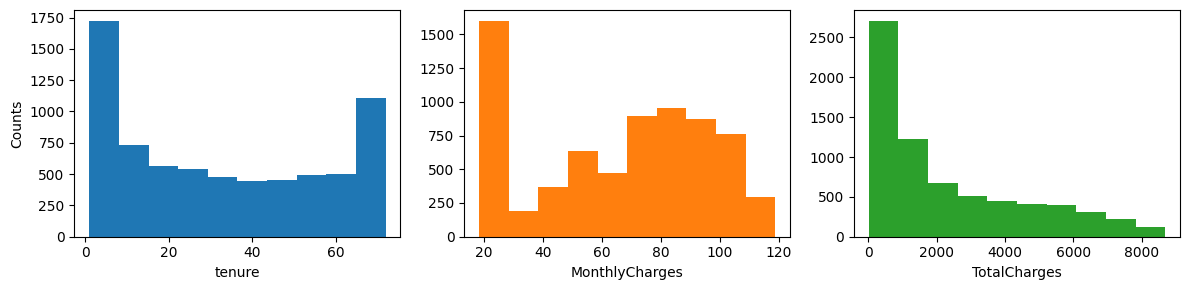

In [20]:
c = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    axs[i].hist(df[numerical_features[i]], color = c[i])
    axs[i].set_xlabel(numerical_features[i])
axs[0].set_ylabel('Counts')
plt.tight_layout()

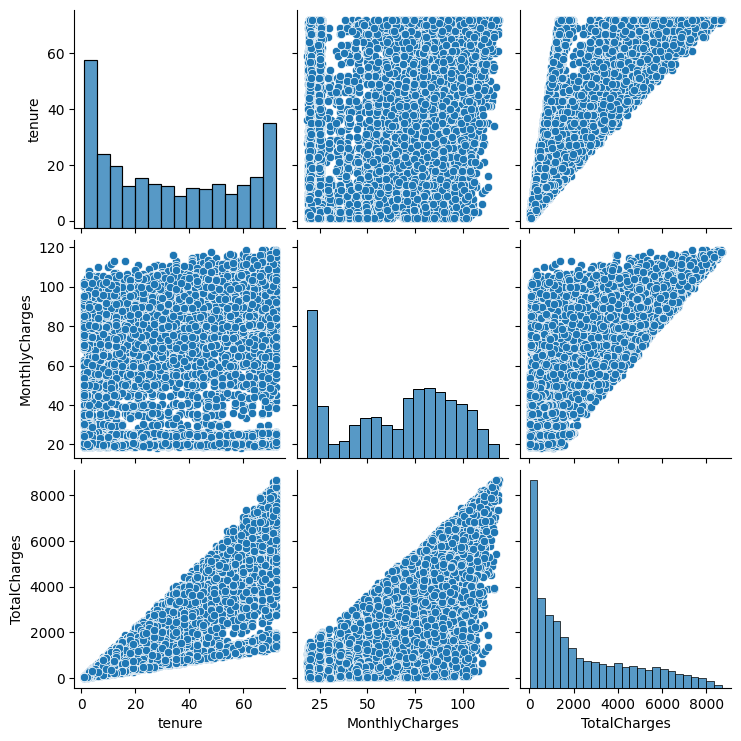

In [21]:
sns.pairplot(df[numerical_features]);

##### Categorical features pie charts

In [22]:
categorical_features = [col for col in df.columns if df[col].dtypes == 'object' and col != 'Churn']

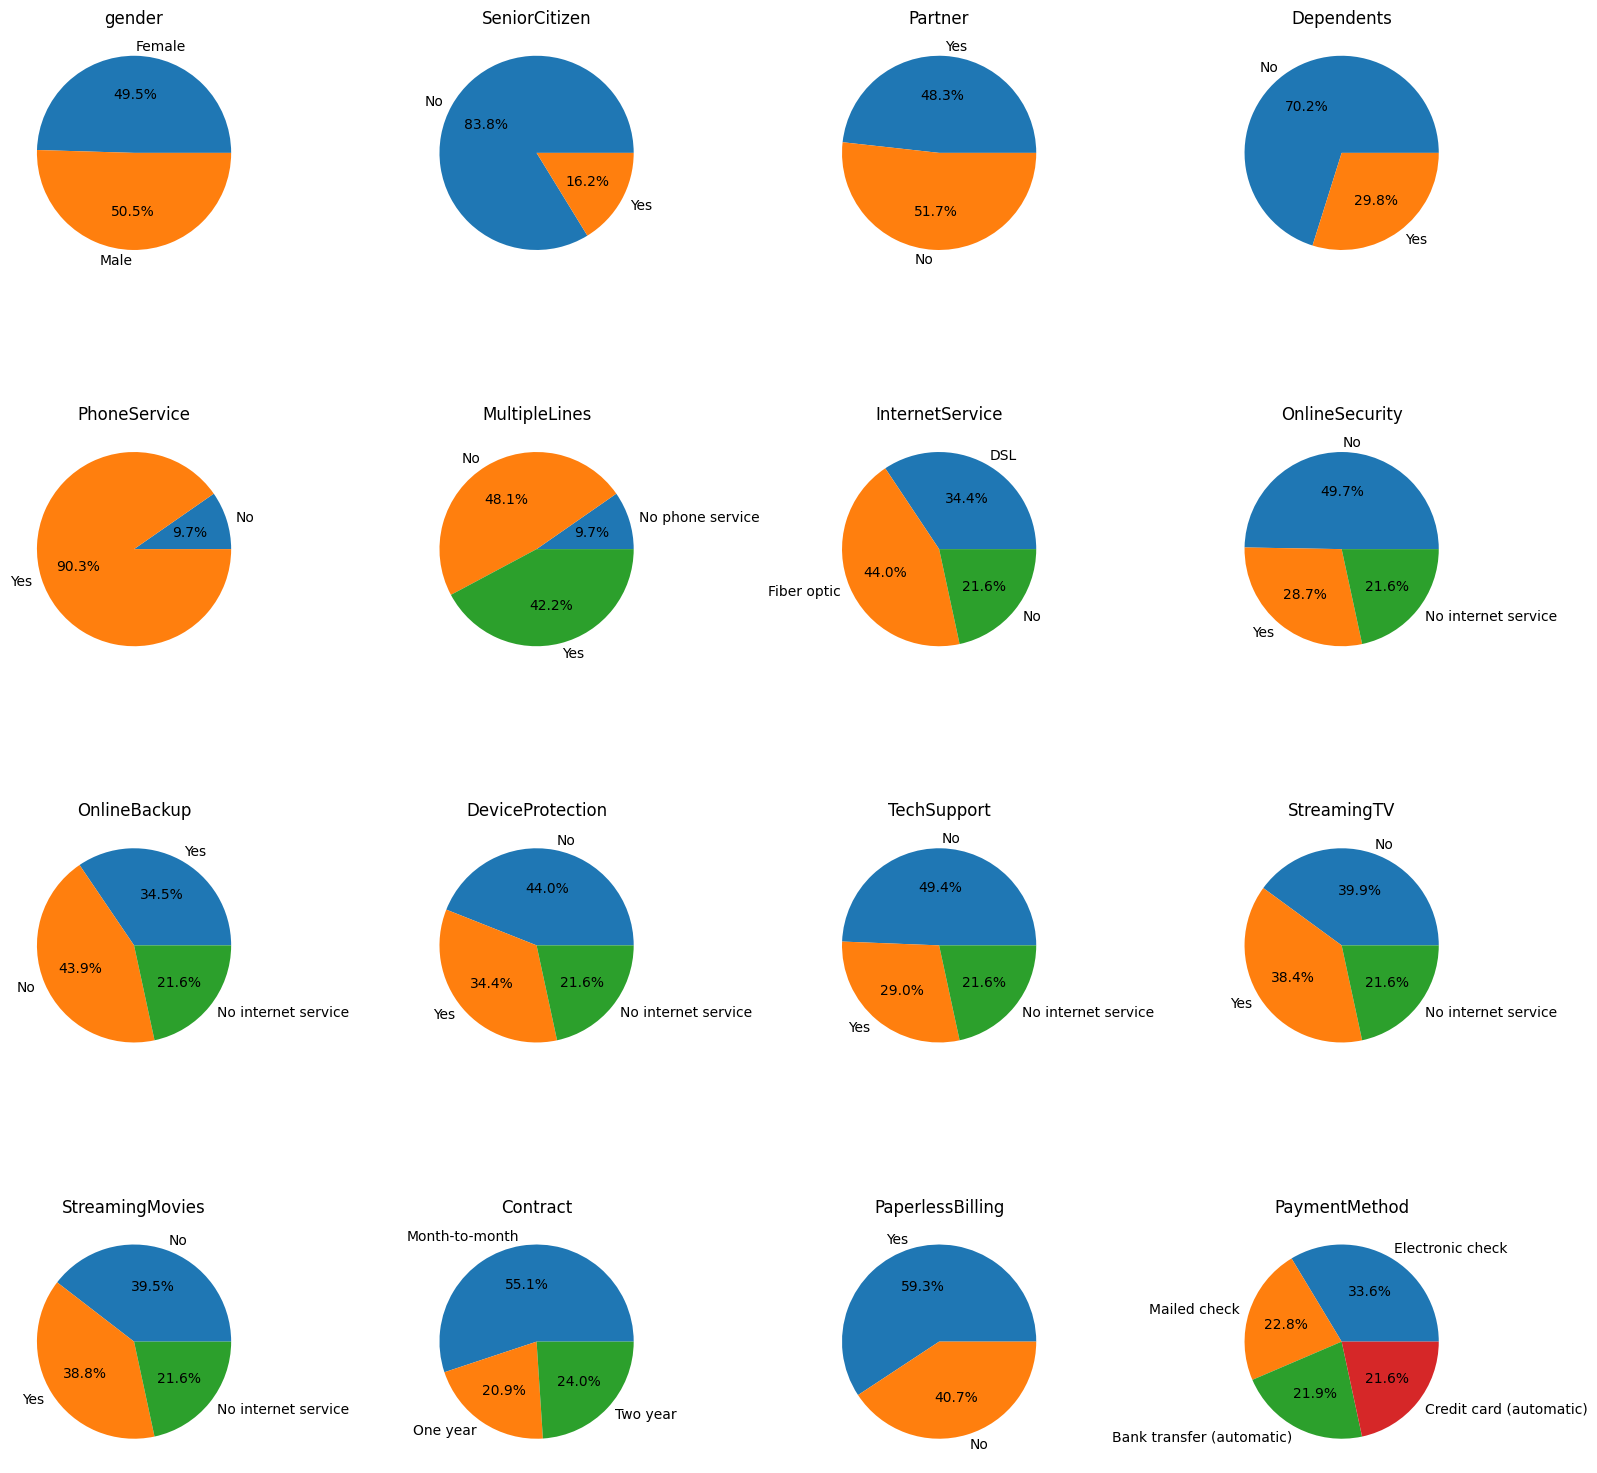

In [23]:
fig, axs = plt.subplots(4,4, figsize = (16,16))
k=0
l=0
for col in categorical_features:
    labels = df[col].unique()
    sizes = [(df[col] == labels[j]).sum() for j in range(len(labels))]

    axs[k,l].pie(sizes, labels = labels, autopct='%1.1f%%', colors = c)
    axs[k,l].set_title(col)
    if l == 3:
        l = 0
        k += 1
    else:
        l += 1
        
plt.tight_layout()

In [24]:
# only captures linear correlation. Not well suited for categories

In [25]:
pd.get_dummies(df).corr()["Churn_Yes"].sort_values() 

Churn_No                                  -1.000000
tenure                                    -0.354049
Contract_Two year                         -0.301552
OnlineBackup_No internet service          -0.227578
DeviceProtection_No internet service      -0.227578
InternetService_No                        -0.227578
OnlineSecurity_No internet service        -0.227578
TechSupport_No internet service           -0.227578
StreamingTV_No internet service           -0.227578
StreamingMovies_No internet service       -0.227578
TotalCharges                              -0.199484
PaperlessBilling_No                       -0.191454
Contract_One year                         -0.178225
OnlineSecurity_Yes                        -0.171270
TechSupport_Yes                           -0.164716
Dependents_Yes                            -0.163128
SeniorCitizen_No                          -0.150541
Partner_Yes                               -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetServ

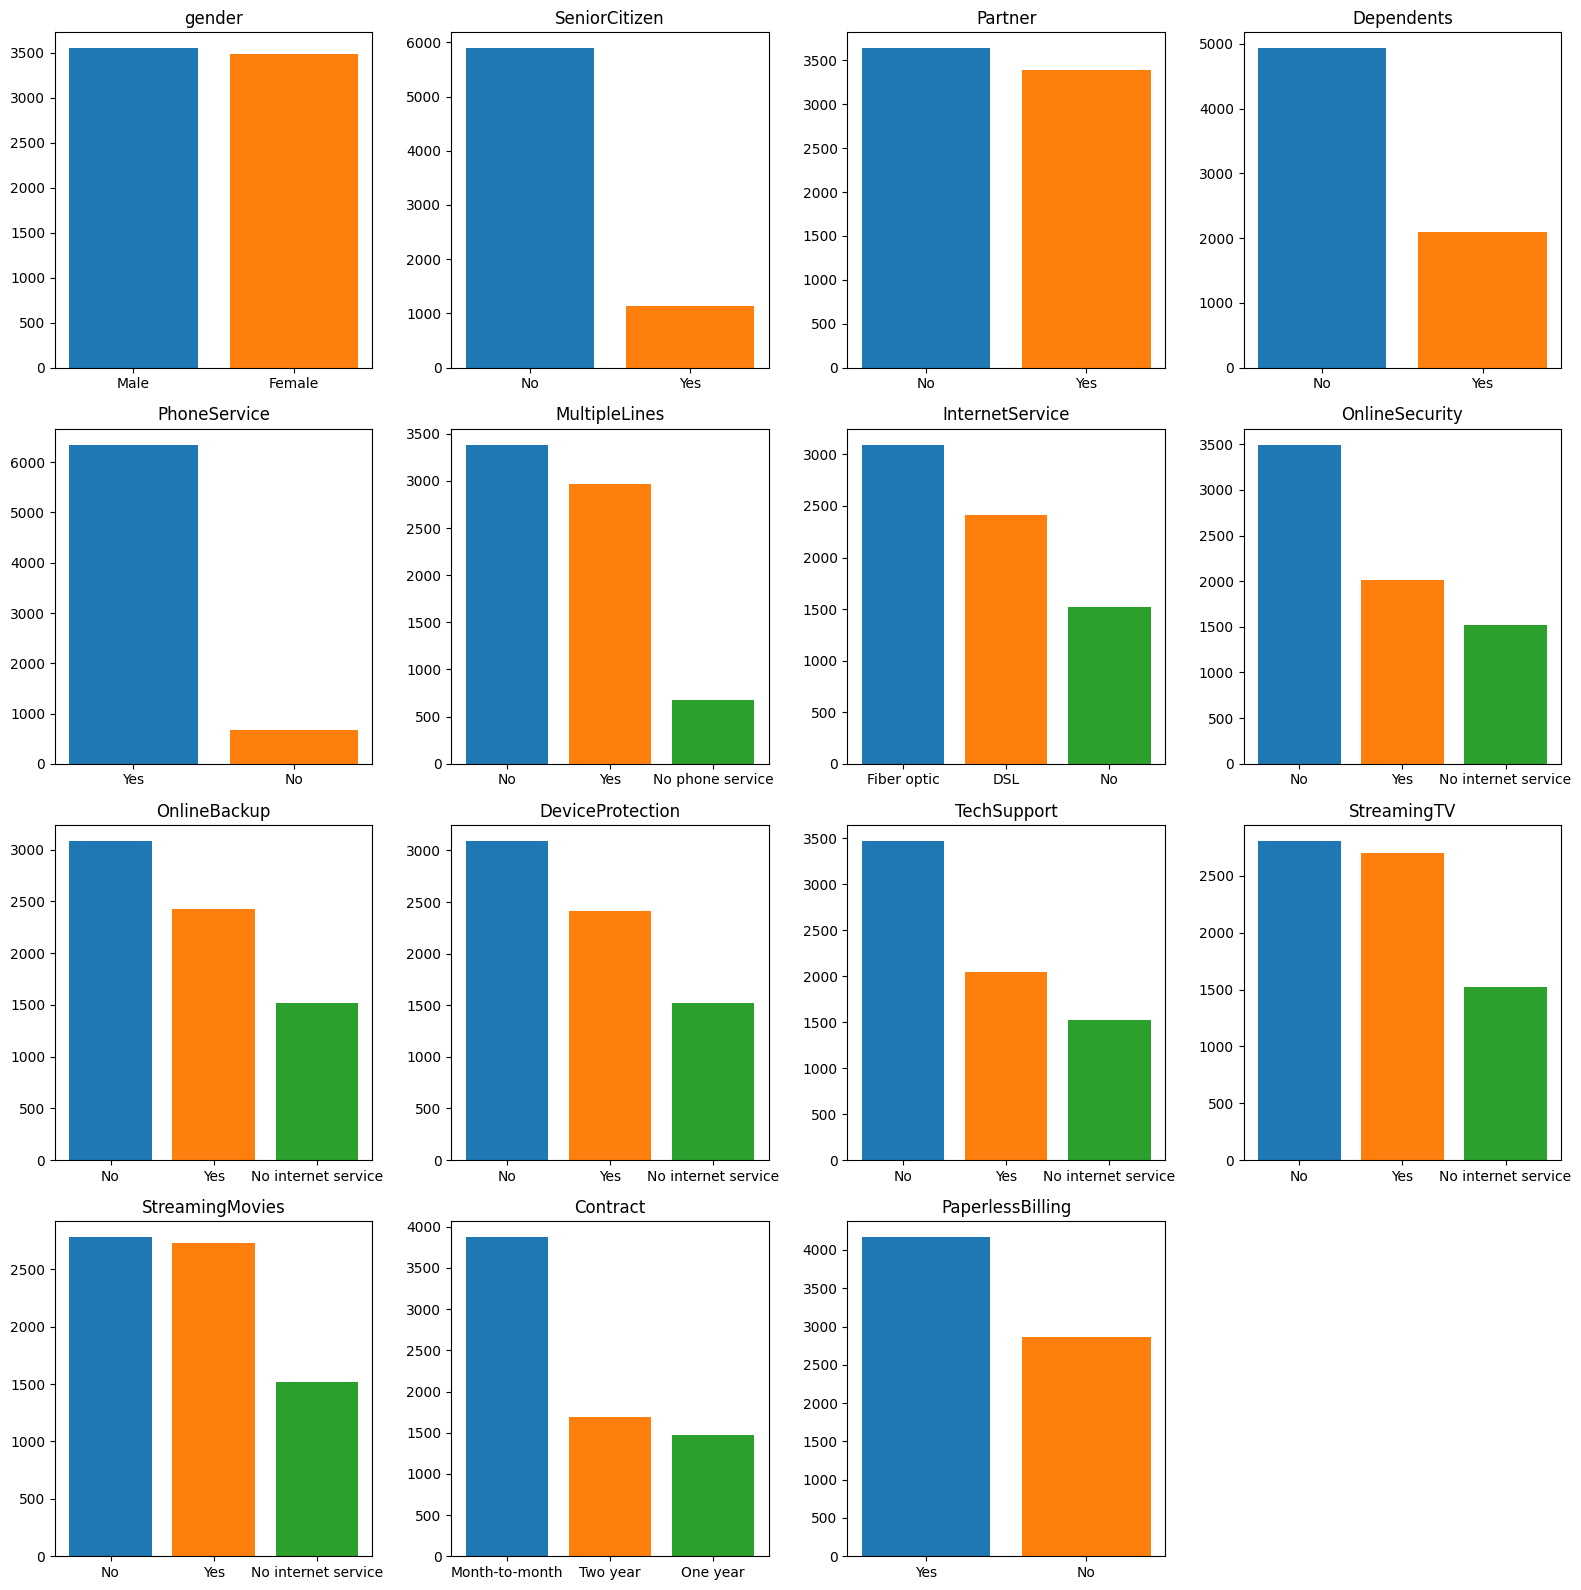

In [26]:
fig, axs = plt.subplots(4,4, figsize = (16,16))
k=0
l=0
for col in categorical_features[:-1]:
    counts = df[col].value_counts()

    axs[k,l].bar(counts.index, counts.values, color = c)
    axs[k,l].set_title(col)
    if l == 3:
        l = 0
        k += 1
    else:
        l += 1

axs[k,l].set_axis_off()
plt.tight_layout()

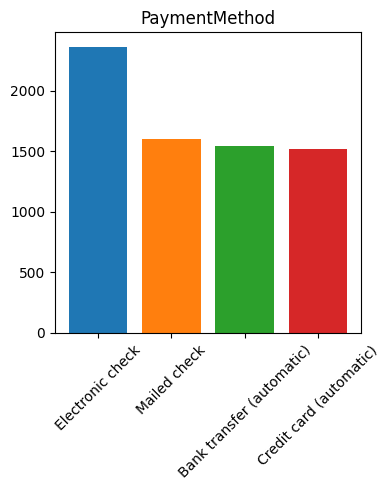

In [27]:
fig, ax = plt.subplots(1,1, figsize = (4,5))

for col in categorical_features[-1:]:
    counts = df[col].value_counts()

    ax.bar(counts.index, counts.values, color = c)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

##### Numerical features histograms w churn

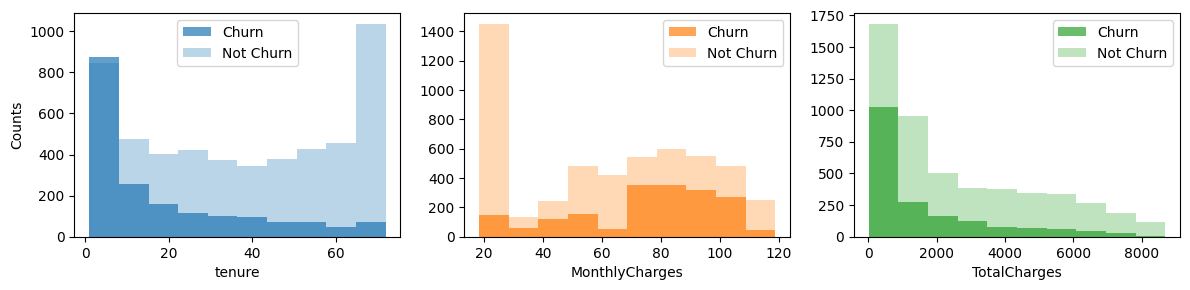

In [28]:
c = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    bins = np.histogram(df[numerical_features[i]].values, bins = 10)[1]
    axs[i].hist(df[df['Churn'] == 'Yes'][numerical_features[i]], color = c[i], alpha = 0.7, bins = bins, label = 'Churn')
    axs[i].hist(df[df['Churn'] == 'No'][numerical_features[i]], color = c[i], alpha = 0.3, bins = bins, label = 'Not Churn')
    axs[i].set_xlabel(numerical_features[i])
    axs[i].legend()
axs[0].set_ylabel('Counts')
plt.tight_layout()

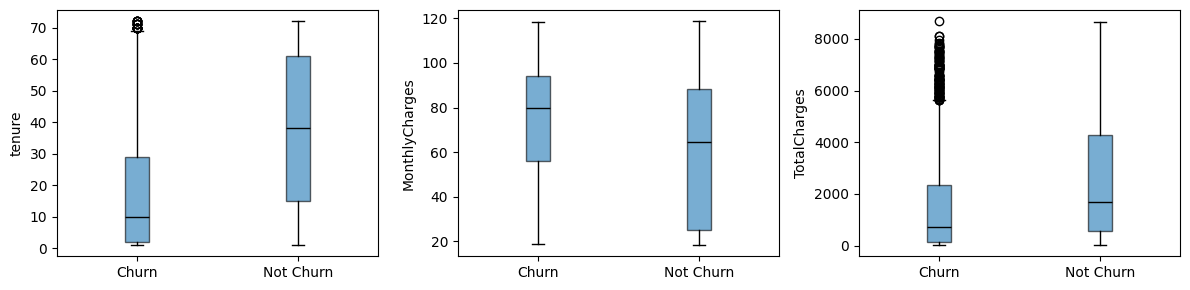

In [29]:
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    axs[i].boxplot([df[df['Churn']=='Yes'][numerical_features[i]],df[df['Churn']=='No'][numerical_features[i]]],
                   patch_artist=True, 
                   boxprops={'facecolor': 'C0', 'alpha' : 0.6},
                   medianprops={'color': 'black'})
    axs[i].set_ylabel(numerical_features[i])
    axs[i].set_xticks([y + 1 for y in range(2)], labels=['Churn', 'Not Churn'])
plt.tight_layout()

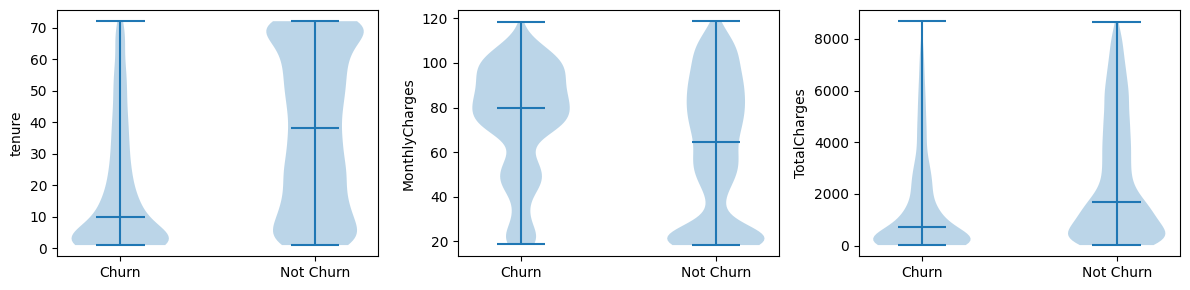

In [30]:
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    axs[i].violinplot([df[df['Churn']=='Yes'][numerical_features[i]],df[df['Churn']=='No'][numerical_features[i]]],showmeans=False,showmedians=True)
    axs[i].set_ylabel(numerical_features[i])
    axs[i].set_xticks([y + 1 for y in range(2)], labels=['Churn', 'Not Churn'])
plt.tight_layout()

##### Categorical features pie charts w churn

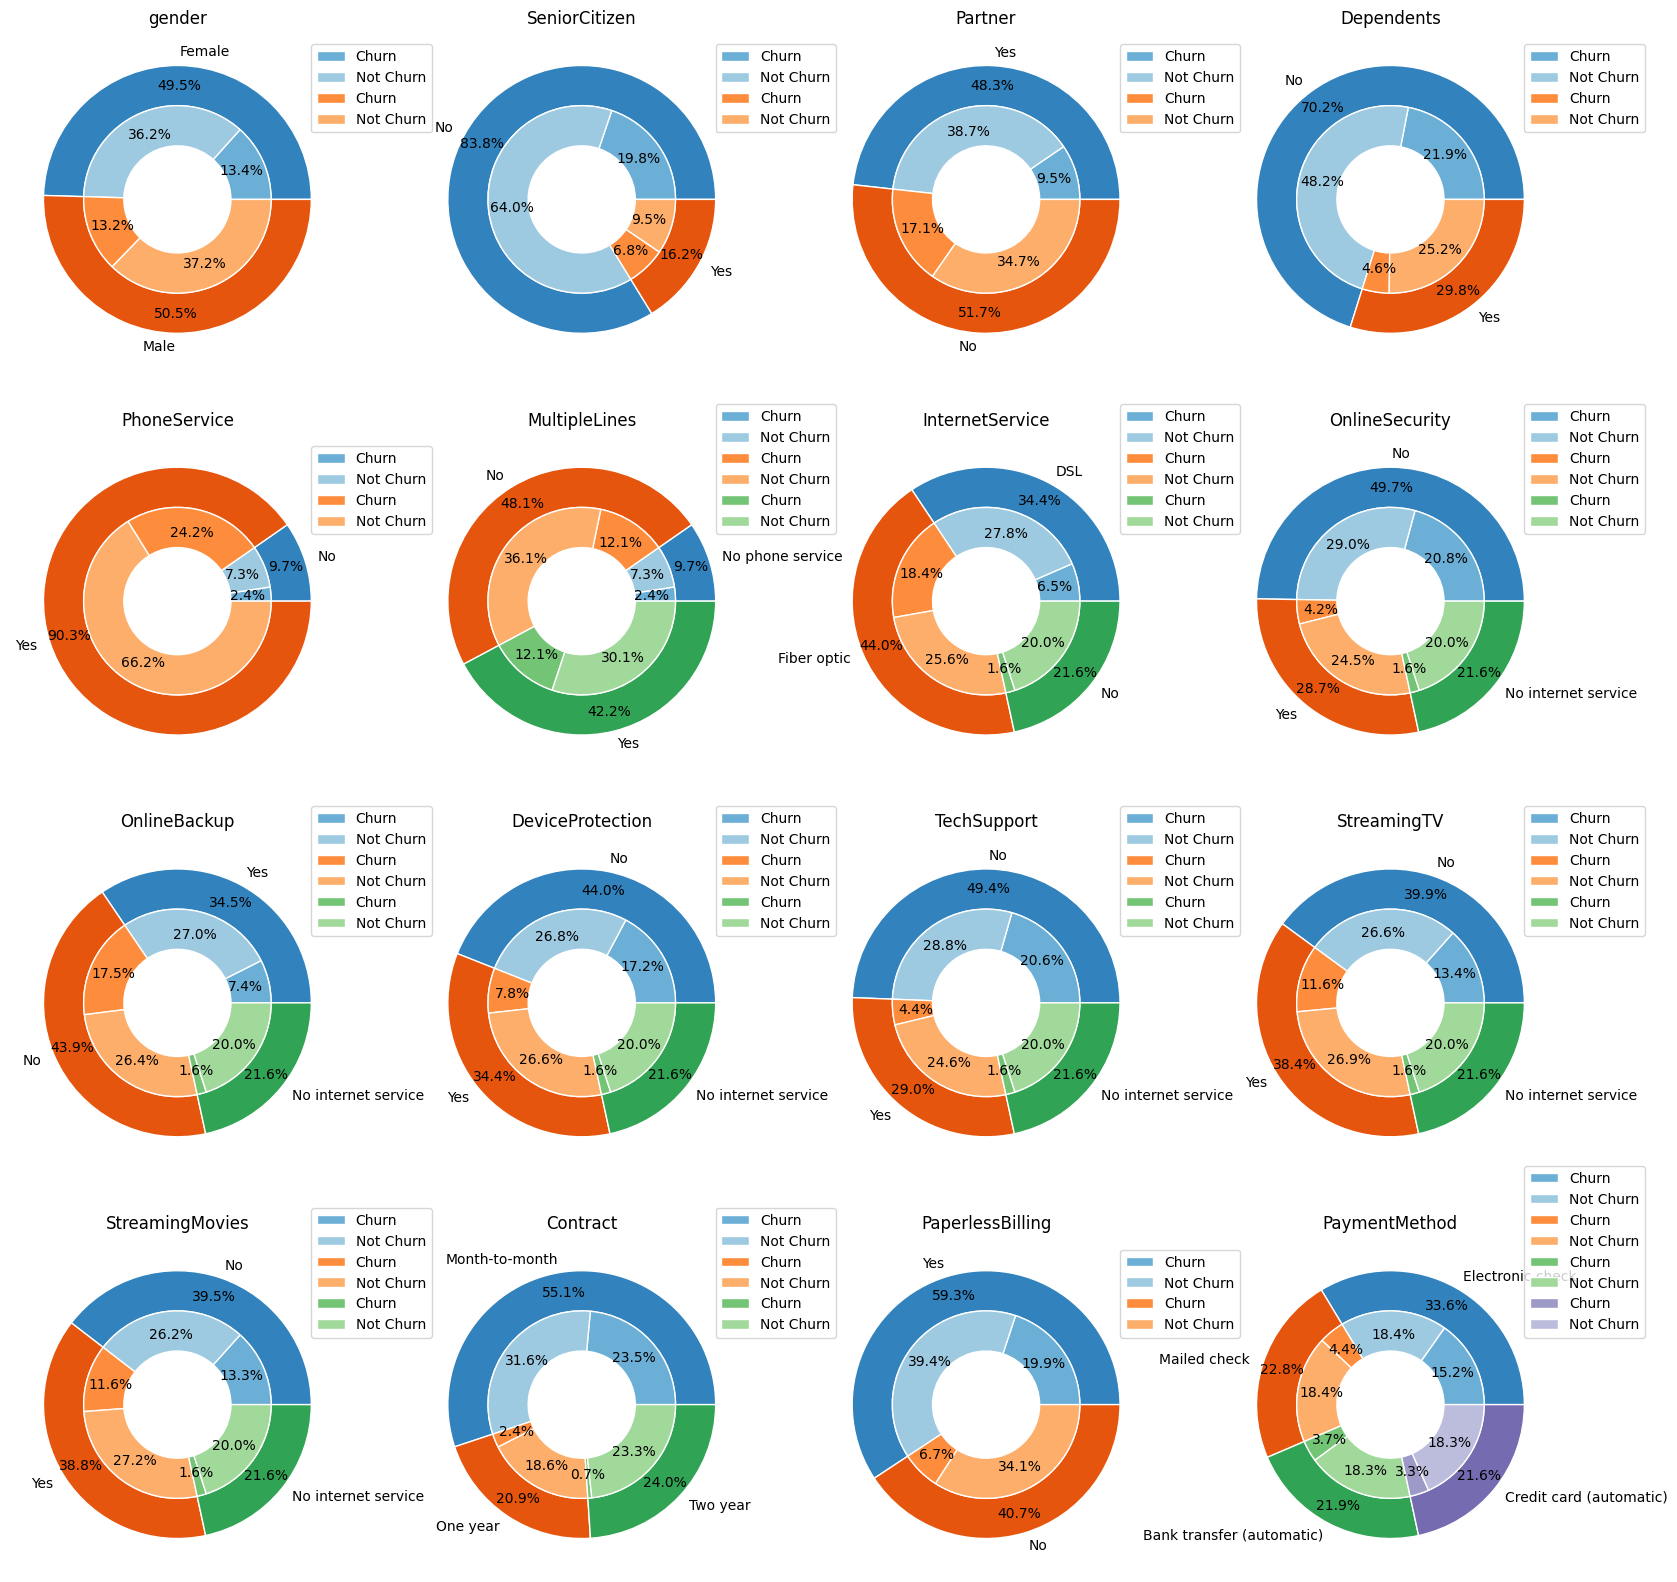

In [31]:
tab20c = plt.color_sequences["tab20c"]
outer_colors = [tab20c[i] for i in [0, 4, 8, 12]]
inner_colors = [tab20c[i] for i in [1, 2, 5, 6, 9, 10, 13, 14]]

fig, axs = plt.subplots(4,4, figsize = (20,20))
k=0
l=0

for col in categorical_features:
    width = 0.3
    group_labels = df[col].unique()
    vals = np.array([[((df[col] == group_labels[j]) & (df['Churn'] == 'Yes')).sum(), ((df[col] == group_labels[j]) & (df['Churn'] == 'No')).sum()] for j in range(len(group_labels))])

    axs[k,l].pie(vals.sum(axis=1), radius=1, colors=outer_colors,
       wedgeprops=dict(width=width, edgecolor='w'), labels = group_labels, autopct='%1.1f%%', pctdistance=0.85)
    axs[k,l].pie(vals.flatten(), radius=1-width, colors=inner_colors,
       wedgeprops=dict(width=width, edgecolor='w'), labels = ['Churn', 'Not Churn']*len(group_labels), labeldistance=None, autopct='%1.1f%%', pctdistance=0.75)

    axs[k,l].set(aspect="equal", title=col)
    handles, labels = axs[k,l].get_legend_handles_labels()
    
    if col == 'Payment Method':
        axs[k,l].legend(handles[len(group_labels):], ['Churn', 'Not Churn']*len(group_labels), loc=(0.9, 0.3)) 
    else:
        axs[k,l].legend(handles[len(group_labels):], ['Churn', 'Not Churn']*len(group_labels), loc=(0.9, 0.7))
    
    if l == 3:
        l = 0
        k += 1
    else:
        l += 1

axs[3,3].set_axis_off()
plt.show()

#### Summary:
- Done: Histograms, box plots and pie charts for each feature

#### Customers Statistics

##### Numerical feature correlation analysis

In [32]:
df[["tenure","MonthlyCharges","TotalCharges"]].corr()    # Monthly Charges and total charges are highly correlated, as expected

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


##### Customers with phone service AND internet Service

In [33]:
len(df[(df["PhoneService"]=="Yes") & (df["InternetService"]!="No")])

4832

In [34]:
4832/7032 # 68.7% of total customers have both Phone service and Internet Service

0.6871444823663254

##### Customers with phone service

In [35]:
len(df[(df["PhoneService"]=="Yes")])

6352

In [36]:
6352/7032 # 90.3% of total customers have Phone service

0.9032992036405005

##### Customers with internet service

In [37]:
len(df[df["InternetService"]!="No"])

5512

In [38]:
5512/7032 # 78.4% of total customers have Internet service

0.7838452787258248

##### Customers with ONLY phone service

In [39]:
len(df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")])

1520

In [40]:
1520/7032 # 21.6% of total customers ONLY have phone service

0.2161547212741752

##### Customers with ONLY internet service

In [41]:
len(df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")])

680

In [42]:
680/7032 # 9.7% of total customers ONLY have internet service

0.09670079635949944

##### Summary:
- 21.6% of total customers only have phone service 

- 9.7% of total customers only have internet service 

- 68.7% of total customers have both internet and phone service

------------------------------------------------------------

- 90.3% of total customers have phone service

- 78.4% of total customers have internet service

##### Month revenue

In [43]:
df["MonthlyCharges"].sum() # This month revenue

np.float64(455661.0)

In [44]:
df["MonthlyCharges"].mean() # Average charge 

np.float64(64.79820819112628)

##### Revenue phone service AND internet service

In [45]:
df[(df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].sum()

np.float64(395070.15)

In [46]:
395070.15/455661.0

0.8670264736284212

In [47]:
df[(df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].mean()

np.float64(81.7612065397351)

##### Revenue ONLY phone service

In [48]:
df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].sum()

np.float64(32035.949999999997)

In [49]:
32035.949999999997/455661.0  # The customers that only have phone service contribute with 7% of this month revenue

0.07030654368049931

In [50]:
df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].mean() # The average revenue contribution for customers with only phone service is $21

np.float64(21.076282894736842)

In [51]:
df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["tenure"].mean()

np.float64(30.667763157894736)

In [52]:
df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["tenure"].median()

np.float64(25.0)

##### Revenue ONLY internet service

In [53]:
df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].sum()

np.float64(28554.9)

In [54]:
28554.9/455661.0   # The customer that only have internet service contribute with 6.3% of this month revenue

0.06266698269107955

In [55]:
df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].mean() # The average revenue contribution for customers with only internet service is $42

41.9925

In [56]:
df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")]["tenure"].mean()

31.830882352941178

In [57]:
df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")]["tenure"].median()

29.0

##### Summary:
- This months total revenue: \\$455661.0 (average customer contribution: \\$64.8)

- This months phone service AND internet service customer contribution: \\$ 395070.15 (86.7\% of total revenue) (average customer contribution: \\$81.8)

- This months ONLY phone service customer contribution: \\$ 32035.95  (7\% of total revenue) (average customer contribution: \\$21.1)

- This months ONLY internet service customer contribution: \\$ 28554.90  (6.3\% of total revenue) (average customer contribution: \\$42)

##### Lost revenue

In [58]:
df[df["Churn"]=="Yes"]["MonthlyCharges"].sum()

139130.85

In [59]:
df[df["Churn"]=="Yes"]["MonthlyCharges"].mean()

74.44133226324237

In [60]:
df[df["Churn"]=="No"]["MonthlyCharges"].mean()

61.307408483439865

In [61]:
df[df["Churn"]=="Yes"]["MonthlyCharges"].sum()/df["MonthlyCharges"].sum()   # The churned contracts represent 30% of this month revenue. Since around 26% of customers churned, we already expected their monthly charges to be higher than the average

0.30533850823309433

##### Lost revenue phone service AND internet service

In [62]:
df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].sum()

130448.50000000001

In [63]:
130448.50000000001/139130.85 # 93.8% of revenue lost

0.9375957956125476

In [64]:
df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].mean()

82.25000000000001

##### Lost revenue ONLY phone service

In [65]:
df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].sum()

2301.6

In [66]:
2301.6/139130.85 # 1.6% of total revenue lost

0.016542700630377806

In [67]:
df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].mean()

20.368141592920352

##### Lost revenue ONLY internet service

In [68]:
df[(df["Churn"]=="Yes") & (df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].sum()

6380.75

In [69]:
6380.75/139130.85  #  4.5% of total revenue lost

0.04586150375707472

In [70]:
df[(df["Churn"]=="Yes") & (df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].mean()

37.53382352941176

##### Summary:
- Total lost revenue: \\$139130.85 (average customer contribution: $74.4)

- Lost revenue phone service AND internet service customer contribution: \\$130448.50 (93.8\% of total revenue lost) (average customer contribution: $82.3)

- Lost revenue ONLY phone service customer contribution: \\$ 2301.60 (1.65\% of total revenue lost) (average customer contribution: $20.4)

- Lost revenue ONLY internet service customer contribution: \\$ 6380.75 (4.59\% of total revenue lost) (average customer contribution: $37.5)

##### Total churned customers

In [71]:
len(df[df["Churn"]=="Yes"])

1869

##### Churned customers with phone service AND internet service

In [72]:
len(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]!="No")])

1586

In [73]:
1586/1869   # 84.9% of churned customer had phone service AND internet service

0.8485821294810059

##### Churned customers with ONLY phone service

In [74]:
len(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]=="No")])

113

In [75]:
113/1869   # 6% of churned customer had only phone service

0.060460139111824504

##### Churned customers with ONLY internet service

In [76]:
len(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="No") & (df["InternetService"]!="No")])

170

In [77]:
170/1869   # 9.1% of churned customer had only internet service

0.0909577314071696

##### Summary:
- Total number of churned customers: 1869

- Number of churned customers with ONLY phone service: 113 (6%)

- Number of churned customers with ONLY internet service: 170 (9.1%)

- Number of churned customers with phone service and internet service: 1586 (84.9%)

We saw previously that 68.7% of customers have both internet and phone services. And we just saw this group comprises 84.9% of the total churned customers, making it a possible churn risk indicator.

Let's take a closer look at its characteristics.

#### Risk Analysis: Phone Service + Internet Service

In [78]:
df_risk=df[(df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]
df_risk.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,No,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No


In [79]:
len(df_risk)

4832

##### Gender

In [80]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [81]:
3549/(3549+3483)

0.5046928327645052

In [82]:
df_risk["gender"].value_counts()

gender
Male      2424
Female    2408
Name: count, dtype: int64

In [83]:
2424/(2424+2408)

0.5016556291390728

##### Senior Citizen

In [84]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

In [85]:
1142/(1142+5890)

0.16240045506257111

In [86]:
df_risk["SeniorCitizen"].value_counts()

SeniorCitizen
No     3846
Yes     986
Name: count, dtype: int64

In [87]:
986/(986+3846)

0.20405629139072848

##### Partner

In [88]:
df["Partner"].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

In [89]:
3393/(3393+3639)

0.4825085324232082

In [90]:
df_risk["Partner"].value_counts()

Partner
No     2481
Yes    2351
Name: count, dtype: int64

In [91]:
2351/(2351+2481)

0.4865480132450331

##### Dependents

In [92]:
df["Dependents"].value_counts()

Dependents
No     4933
Yes    2099
Name: count, dtype: int64

In [93]:
2099/(2099+4933)

0.2984926052332196

In [94]:
df_risk["Dependents"].value_counts()

Dependents
No     3574
Yes    1258
Name: count, dtype: int64

In [95]:
1258/(1258+3574)

0.2603476821192053

##### Multiple Lines

In [96]:
df["MultipleLines"].value_counts()

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

In [97]:
2967/(2967+3385)

0.4670969773299748

In [98]:
df_risk["MultipleLines"].value_counts()

MultipleLines
Yes    2627
No     2205
Name: count, dtype: int64

In [99]:
2627/(2627+2205)

0.5436672185430463

##### Internet Service

In [100]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [101]:
3096/(3096+2416)

0.5616835994194485

In [102]:
2416/(3096+2416)

0.43831640058055155

In [103]:
df_risk["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            1736
Name: count, dtype: int64

In [104]:
3096/(3096+1736)    # All with fiber optics have phone service??? Yes, checked.

0.640728476821192

In [105]:
1736/(1736+3096)

0.35927152317880795

##### Online Security

In [106]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

In [107]:
2015/(2015+3497)

0.36556603773584906

In [108]:
df_risk["OnlineSecurity"].value_counts()

OnlineSecurity
No     3098
Yes    1734
Name: count, dtype: int64

In [109]:
1734/(1734+3098)

0.35885761589403975

##### Online Backup

In [110]:
df["OnlineBackup"].value_counts()

OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

In [111]:
2425/(2425+3087)

0.4399492017416546

In [112]:
df_risk["OnlineBackup"].value_counts()

OnlineBackup
No     2693
Yes    2139
Name: count, dtype: int64

In [113]:
2139/(2139+2693)

0.44267384105960267

##### Device Protection

In [114]:
df["DeviceProtection"].value_counts()

DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

In [115]:
2418/(2418+3094)

0.4386792452830189

In [116]:
df_risk["DeviceProtection"].value_counts()

DeviceProtection
No     2717
Yes    2115
Name: count, dtype: int64

In [117]:
2115/(2115+2717)

0.4377069536423841

##### Tech Support

In [118]:
df["TechSupport"].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

In [119]:
2040/(2040+3472)

0.37010159651669083

In [120]:
df_risk["TechSupport"].value_counts()

TechSupport
No     3079
Yes    1753
Name: count, dtype: int64

In [121]:
1753/(1753+3079)

0.36278973509933776

##### Streaming TV

In [122]:
df["StreamingTV"].value_counts()

StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

In [123]:
2703/(2703+2809)

0.49038461538461536

In [124]:
df_risk["StreamingTV"].value_counts()

StreamingTV
Yes    2420
No     2412
Name: count, dtype: int64

In [125]:
2420/(2420+2412)

0.5008278145695364

##### Streaming Movies

In [126]:
df["StreamingMovies"].value_counts()

StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64

In [127]:
2731/(2731+2781)

0.4954644412191582

In [128]:
df_risk["StreamingMovies"].value_counts()

StreamingMovies
Yes    2433
No     2399
Name: count, dtype: int64

In [129]:
2433/(2433+2399)

0.5035182119205298

##### Contract

In [130]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [131]:
3875/(3875+1685+1472)

0.551052332195677

In [132]:
1685/(1685+3875+1472) #2y

0.2396188850967008

In [133]:
1472/(1472+3875+1685) #1y

0.20932878270762229

In [134]:
df_risk["Contract"].value_counts()

Contract
Month-to-month    2975
One year           964
Two year           893
Name: count, dtype: int64

In [135]:
2975/(2975+964+893)

0.6156870860927153

In [136]:
893/(964+2975+893) #2y

0.18480960264900662

In [137]:
964/(2975+964+893) #1y

0.19950331125827814

##### Paperless Billing

In [138]:
df["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64

In [139]:
4168/(4168+2864)

0.5927189988623436

In [140]:
df_risk["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    3337
No     1495
Name: count, dtype: int64

In [141]:
3337/(3337+1495)

0.6906043046357616

##### Payment Method

In [142]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [143]:
2365/(2365+1604+1542+1521) # Electronic check

0.3363196814562002

In [144]:
1604/(2365+1604+1542+1521) # Mailed check 

0.22810011376564276

In [145]:
1542/(2365+1604+1542+1521) # Bank transfer (automatic)

0.21928327645051193

In [146]:
1521/(2365+1604+1542+1521) # Credit card (automatic)

0.21629692832764505

In [147]:
df_risk["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2017
Bank transfer (automatic)    1068
Credit card (automatic)      1037
Mailed check                  710
Name: count, dtype: int64

In [148]:
2017/(2017+1068+1037+710) # Electronic check

0.41742549668874174

In [149]:
1068/(2017+1068+1037+710) # Bank transfer (automatic)

0.22102649006622516

In [150]:
1037/(2017+1068+1037+710) # Credit card (automatic)

0.2146109271523179

In [151]:
710/(2017+1068+1037+710) # Mailed check 

0.14693708609271522

##### Churn

In [152]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [153]:
1869/(1869+5163)

0.26578498293515357

In [154]:
df_risk["Churn"].value_counts()

Churn
No     3246
Yes    1586
Name: count, dtype: int64

In [155]:
1586/(1586+3246)

0.32822847682119205

##### Tenure, Monthly Charges, Total Charges

In [156]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


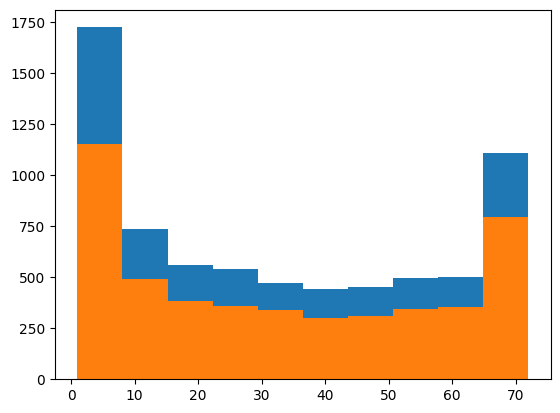

In [157]:
plt.hist(df["tenure"])
plt.hist(df_risk["tenure"]);

In [158]:
df_risk.describe()

,tenure,MonthlyCharges,TotalCharges
count,4832.000000,4832.000000,4832.000000
mean,33.056705,81.761207,2902.470788
std,24.636200,18.306134,2415.564128
min,1.000000,42.900000,42.900000
25%,9.000000,69.787500,659.600000
50%,30.000000,82.500000,2350.625000
75%,56.000000,95.700000,4871.150000
max,72.000000,118.750000,8684.800000


#### Summary: 
Possible risk group with 32.8% churn: combination Internet Service + Phone Service formed of 4832 customers (68.7% of total customers).

- No significant difference in the proportion of male/female, number of customers with partners, in customers with/without online security, online backup, device protection, tech support, streaming TV and streaming Movies.

- More senior citizens in this group: 20.4% against 16.2% in the general group

- Less customers with dependents in this group: 26% against 29.8% in the general group

- More customers with multiple lines: 54.4% against 46.7% in the general group

- The customer have more fiber optic than DSL internet: 64%/36% against 56%/44% in the general group

- There are more month to month contracts and less 1y, 2y (m-m/1y/2y): 61.6%/20%/18.5% against 55%/21%/24% in the general group

- More paperless billing: 69% against 59% in the general group

- Electronic check payments grew, while mailed check payments reduced, they are 41.7% (Electronic check) 14.7% (Mailed check) against 33.6% (Electronic check) 22.8% (Mailed check) in the general group

- The customers from this group churn more: 32.8% against 26.6% in the general group

- Similar tenure average(median) 33(30) months against 32.4(29) months in the general group

- Higher monthly charges average(median) \\$81.76(\\$82.5) against \\$64.8(\\$70.35) in the general group

- Higher total charges average(median) \\$2902.5(\\$2350.6) against \\$2283.3(\\$1397.5) in the general group

#### Risk analysis: partner + dependents

In [159]:
df[(df["Partner"]=="Yes") & (df["Dependents"]=="Yes")]["Churn"].value_counts()

Churn
No     1491
Yes     249
Name: count, dtype: int64

In [160]:
249/(249+1491) # Only 14.3% of customer with partner and dependents churn

0.14310344827586208

In [161]:
(249+1491)/7032 # Customers with partner and dependents represent 24.7% of total customers

0.24744027303754265

In [162]:
df[(df["Partner"]=="Yes") & (df["Dependents"]=="Yes")].describe()

,tenure,MonthlyCharges,TotalCharges
count,1740.000000,1740.000000,1740.000000
mean,41.578161,61.070805,2746.914914
std,23.622272,31.649204,2358.492234
min,1.000000,18.700000,18.800000
25%,20.000000,24.687500,761.275000
50%,45.000000,65.125000,1833.275000
75%,65.000000,88.850000,4559.975000
max,72.000000,118.750000,8672.450000


In [163]:
df[(df["Partner"]=="No") & (df["Dependents"]=="No")]["Churn"].value_counts()

Churn
No     2157
Yes    1123
Name: count, dtype: int64

In [164]:
1123/(1123+2157)  # 34% of customers with no partner nor dependents churn

0.34237804878048783

In [165]:
(1123+2157)

3280

In [166]:
(1123+2157)/7032  # customers with no partner nor dependents represent 46.6% of the total number of customers

0.4664391353811149

In [167]:
df[(df["Partner"]=="No") & (df["Dependents"]=="No")].describe()

,tenure,MonthlyCharges,TotalCharges
count,3280.000000,3280.000000,3280.000000
mean,23.303354,62.983735,1610.702439
std,21.854290,28.925200,1899.021150
min,1.000000,18.250000,18.850000
25%,4.000000,36.600000,193.600000
50%,16.000000,69.700000,810.650000
75%,39.000000,86.000000,2404.325000
max,72.000000,118.650000,8547.150000


#### Summary:
Possible risk group with 34% churn: combination No partner + No dependents formed of 3280 customers (46.6% of total customers).

- Customers with partners and dependents churn less than customers without both: 14% against 34%, and they represent 24.7% and 46.6% of the total customers, respectively. Customers with partner and dependents have higher tenure, higher total charges and similar monthly charges, when comparing to customers without partner nor dependents.

#### Risk analysis: fiber optics + tech support

In [168]:
df[df["InternetService"]=="Fiber optic"]["Churn"].value_counts()

Churn
No     1799
Yes    1297
Name: count, dtype: int64

In [169]:
1297/(1297+1799) # 42% of Fiber Optics customers churn

0.4189276485788114

In [170]:
(1297+1799)/7032 # 44% of the total customers have fiber optics

0.4402730375426621

In [171]:
df[(df["InternetService"]=="Fiber optic") & (df["TechSupport"]=="No")]["Churn"].value_counts()

Churn
No     1129
Yes    1101
Name: count, dtype: int64

In [172]:
1101/(1101+1129)  # 49% of customers with Fiber Optic and without Tech Support churn

0.49372197309417043

In [173]:
(1101+1129)

2230

In [174]:
(1101+1129)/7032  # 32% of the total customer have fiber optic and no tech support

0.3171217292377702

In [175]:
df[(df["InternetService"]=="Fiber optic") & (df["TechSupport"]=="Yes")]["Churn"].value_counts()

Churn
No     670
Yes    196
Name: count, dtype: int64

In [176]:
196/(196+670)    # 23% of customers with Fiber Optic and Tech Support churn

0.22632794457274827

In [177]:
(196+670)/7032    # 12.3% of the total customer have fiber optic and tech support

0.12315130830489192

#### Summary:
Possible risk group with 49% churn: combination Fiber Optic + No tech support formed of 2230 customers (32% of total customers).

- Customers with fiber optic and tech support churn less than customers with fiber optic and no tech support: 23% against 49%, and they represent 12.3% and 32% of the total customers, respectively.

#### Evaluating number of services per customer

In [178]:
services=df[["PhoneService","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]]
services.head()

,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,No,DSL,No,Yes,No,No,No,No
1,Yes,DSL,Yes,No,Yes,No,No,No
2,Yes,DSL,Yes,Yes,No,No,No,No
3,No,DSL,Yes,No,Yes,Yes,No,No
4,Yes,Fiber optic,No,No,No,No,No,No


In [179]:
mapping={"Yes":1, "Fiber optic":1, "DSL":1, "No":0, "No internet service":0}

In [180]:
for col in services.columns:
    services.loc[:,col]=services.loc[:,col].map(mapping)

In [181]:
services.head()

,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0,1,0,1,0,0,0,0
1,1,1,1,0,1,0,0,0
2,1,1,1,1,0,0,0,0
3,0,1,1,0,1,1,0,0
4,1,1,0,0,0,0,0,0


In [182]:
services.isna().sum()

PhoneService        0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

In [183]:
n_of_services=services.sum(axis=1).to_frame()
n_of_services.columns=["# of services"]
n_of_services.head()

,# of services
0,2
1,4
2,4
3,4
4,2


In [184]:
df_services=pd.concat((df,services.sum(axis=1).to_frame().rename(columns={0:"n_services"})),axis=1)
df_services.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,n_services
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,4
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2


In [185]:
df_services[df_services["Churn"]=="No"].describe(include=['O'])

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,n_services
count,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,1,8
top,Male,No,Yes,No,Yes,No,DSL,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,No,1
freq,2619,4497,2724,3390,4653,2536,1957,2036,1902,1883,2026,1889,1913,2220,2768,1296,5163,1452


##### Numeric features and number of services

In [186]:
df_numeric_services=df_services[["n_services","tenure","MonthlyCharges","TotalCharges", "Churn"]]
df_numeric_services.head()

,n_services,tenure,MonthlyCharges,TotalCharges,Churn
0,2,1,29.85,29.85,No
1,4,34,56.95,1889.50,No
2,4,2,53.85,108.15,Yes
3,4,45,42.30,1840.75,No
4,2,2,70.70,151.65,Yes


In [187]:
gb_df_numeric_services=df_services.groupby(by=["n_services","Churn"])[["tenure","MonthlyCharges","TotalCharges"]].mean().reset_index()
gb_df_numeric_services.head()

,n_services,Churn,tenure,MonthlyCharges,TotalCharges
0,1,No,31.861570,21.251653,692.854408
1,1,Yes,7.182432,21.424662,154.524324
2,2,No,15.377841,54.793892,851.449858
3,2,Yes,6.874667,61.045200,421.929333
4,3,No,23.369449,61.171847,1425.161901


In [188]:
# Monthly Charges average for churn and not churn per number of services

In [189]:
fig = px.bar(gb_df_numeric_services, x="n_services", y="MonthlyCharges",color="Churn", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [190]:
# Total Charges average for churn and not churn per number of services

In [191]:
fig = px.bar(gb_df_numeric_services, x="n_services", y="TotalCharges",color="Churn", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

##### Summary:
- The average monthly charge of churned customers is always higher than that of the non churned customers when looking in term of number of services.

- The opposite happens for total charges and tenure in term of number of services.

##### Number of churn/no churn per number of services

In [192]:
group=df_services.groupby(by=["Churn","n_services"]).size().reset_index(name="count")
group.head()

,Churn,n_services,count
0,No,1,1452
1,No,2,352
2,No,3,563
3,No,4,680
4,No,5,771


In [193]:
total_counts={}
for val in group["n_services"].unique():
    total_counts[val]=group[group["n_services"]==val]["count"].sum()

In [194]:
for i in range(len(group)):
    group.loc[i,"percent"]=str(round(100*group.loc[i,"count"]/total_counts[group["n_services"][i]],1))+"%"

In [195]:
# Churn rate as a function of number of subscribed services.

In [196]:
fig = px.bar(group, x="n_services", y="count",color="Churn", text="percent", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(textposition='outside')
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

##### Summary:
- Customers with only 1 service or with 8 services have less than 10% chance of churn.

- The higher churn rates happen for clients with 2, 3 or 4 services. Let's take a look at this subgroups

#### Risk analysis: customers with 2, 3 or 4 subscribed services

In [197]:
df_service_risk=df_services[df_services["n_services"].isin([2,3,4])]

In [198]:
len(df_service_risk)

2764

In [199]:
df_service_risk["Churn"].value_counts()

Churn
No     1595
Yes    1169
Name: count, dtype: int64

In [200]:
1169/(1169+1595)

0.42293777134587557

In [201]:
(1169+1595)/7032

0.3930602957906712

In [202]:
df[df["Churn"]=="Yes"]["MonthlyCharges"].sum()   # Total lost revenue

139130.85

In [203]:
df_service_risk[df_service_risk["Churn"]=="Yes"]["MonthlyCharges"].sum()   

83041.15

In [204]:
83041.15/139130.85

0.5968564843814294

In [205]:
df["Churn"].value_counts()   # Total churn

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [206]:
1169/1869

0.6254681647940075

##### Summary:
- Customers with only 2, 3 or 4 services sum 39.3% of total customers. Of those, 42.3% churn.

- The churners from this group represent 62.5% of total churners

- These 62.5% churners are responsible for 59.7% lost revenue

##### Gender

In [207]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [208]:
3549/(3549+3483)

0.5046928327645052

In [209]:
df_service_risk["gender"].value_counts()

gender
Male      1397
Female    1367
Name: count, dtype: int64

In [210]:
1397/(1397+1367)

0.5054269175108539

##### Senior Citizen

In [211]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

In [212]:
1142/(1142+5890)

0.16240045506257111

In [213]:
df_service_risk["SeniorCitizen"].value_counts()

SeniorCitizen
No     2188
Yes     576
Name: count, dtype: int64

In [214]:
576/(576+2188)

0.20839363241678727

##### Partner

In [215]:
df["Partner"].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

In [216]:
3393/(3393+3639)

0.4825085324232082

In [217]:
df_service_risk["Partner"].value_counts()

Partner
No     1768
Yes     996
Name: count, dtype: int64

In [218]:
996/(996+1768)

0.36034732272069464

##### Dependents

In [219]:
df["Dependents"].value_counts()

Dependents
No     4933
Yes    2099
Name: count, dtype: int64

In [220]:
2099/(2099+4933)

0.2984926052332196

In [221]:
df_service_risk["Dependents"].value_counts()

Dependents
No     2183
Yes     581
Name: count, dtype: int64

In [222]:
581/(581+2183)

0.2102026049204052

##### Multiple Lines

In [223]:
df["MultipleLines"].value_counts()

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

In [224]:
2967/(2967+3385)

0.4670969773299748

In [225]:
df_service_risk["MultipleLines"].value_counts()

MultipleLines
No                  1348
Yes                 1006
No phone service     410
Name: count, dtype: int64

In [226]:
1006/(1006+1348)

0.42735768903993204

##### Internet Service

In [227]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [228]:
3096/(3096+2416)

0.5616835994194485

In [229]:
2416/(3096+2416)

0.43831640058055155

In [230]:
df_service_risk["InternetService"].value_counts()

InternetService
Fiber optic    1529
DSL            1235
Name: count, dtype: int64

In [231]:
1529/(1529+1235)   

0.5531837916063675

In [232]:
1235/(1529+1235)

0.4468162083936324

##### Online Security

In [233]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

In [234]:
2015/(2015+3497)

0.36556603773584906

In [235]:
df_service_risk["OnlineSecurity"].value_counts()

OnlineSecurity
No     2217
Yes     547
Name: count, dtype: int64

In [236]:
547/(547+2217)

0.1979015918958032

##### Online Backup

In [237]:
df["OnlineBackup"].value_counts()

OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

In [238]:
2425/(2425+3087)

0.4399492017416546

In [239]:
df_service_risk["OnlineBackup"].value_counts()

OnlineBackup
No     2125
Yes     639
Name: count, dtype: int64

In [240]:
639/(639+2125)

0.23118668596237338

##### Device Protection

In [241]:
df["DeviceProtection"].value_counts()

DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

In [242]:
2418/(2418+3094)

0.4386792452830189

In [243]:
df_service_risk["DeviceProtection"].value_counts()

DeviceProtection
No     2255
Yes     509
Name: count, dtype: int64

In [244]:
509/(509+2255)

0.1841534008683068

##### Tech Support

In [245]:
df["TechSupport"].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

In [246]:
2040/(2040+3472)

0.37010159651669083

In [247]:
df_service_risk["TechSupport"].value_counts()

TechSupport
No     2329
Yes     435
Name: count, dtype: int64

In [248]:
435/(435+2329)

0.1573806078147612

##### Streaming TV

In [249]:
df["StreamingTV"].value_counts()

StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

In [250]:
2703/(2703+2809)

0.49038461538461536

In [251]:
df_service_risk["StreamingTV"].value_counts()

StreamingTV
No     2084
Yes     680
Name: count, dtype: int64

In [252]:
680/(680+2084)

0.2460202604920405

##### Streaming Movies

In [253]:
df["StreamingMovies"].value_counts()

StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64

In [254]:
2731/(2731+2781)

0.4954644412191582

In [255]:
df_service_risk["StreamingMovies"].value_counts()

StreamingMovies
No     2086
Yes     678
Name: count, dtype: int64

In [256]:
678/(678+2086)

0.24529667149059334

##### Contract

In [257]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [258]:
3875/(3875+1685+1472)

0.551052332195677

In [259]:
1685/(1685+3875+1472) #2y

0.2396188850967008

In [260]:
1472/(1472+3875+1685) #1y

0.20932878270762229

In [261]:
df_service_risk["Contract"].value_counts()

Contract
Month-to-month    2326
One year           319
Two year           119
Name: count, dtype: int64

In [262]:
2326/(2326+319+119)

0.841534008683068

In [263]:
119/(2326+319+119) #2y

0.04305354558610709

In [264]:
319/(2326+319+119) #1y

0.11541244573082489

##### Paperless Billing

In [265]:
df["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64

In [266]:
4168/(4168+2864)

0.5927189988623436

In [267]:
df_service_risk["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    1856
No      908
Name: count, dtype: int64

In [268]:
1856/(1856+908)

0.6714905933429812

##### Payment Method

In [269]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [270]:
2365/(2365+1604+1542+1521) # Electronic check

0.3363196814562002

In [271]:
1604/(2365+1604+1542+1521) # Mailed check

0.22810011376564276

In [272]:
1542/(2365+1604+1542+1521) # Bank transfer (automatic)

0.21928327645051193

In [273]:
1521/(2365+1604+1542+1521) # Credit card (automatic)

0.21629692832764505

In [274]:
df_service_risk["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             1328
Mailed check                  541
Bank transfer (automatic)     453
Credit card (automatic)       442
Name: count, dtype: int64

In [275]:
1328/(1328+541+453+442) # Electronic check

0.4804630969609262

In [276]:
541/(1328+541+453+442) # Mailed check

0.19573082489146165

In [277]:
453/(1328+541+453+442) # Bank transfer (automatic)

0.16389290882778582

In [278]:
442/(1328+541+453+442) # Credit card (automatic)

0.15991316931982633

##### Churn

In [279]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [280]:
1869/(1869+5163)

0.26578498293515357

In [281]:
df_service_risk["Churn"].value_counts()

Churn
No     1595
Yes    1169
Name: count, dtype: int64

In [282]:
1169/(1169+1595)

0.42293777134587557

##### Tenure, Monthly Charges, Total Charges

In [283]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


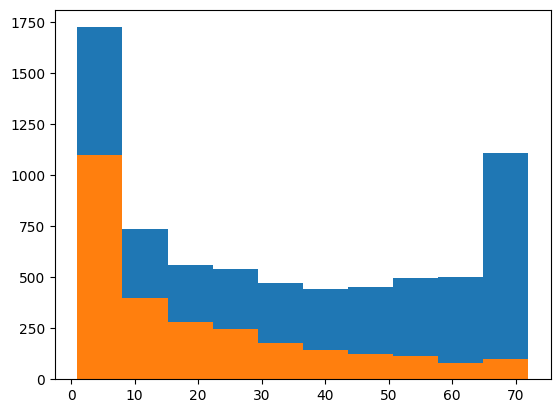

In [284]:
plt.hist(df["tenure"])
plt.hist(df_service_risk["tenure"]);

In [285]:
df_service_risk.describe()

,tenure,MonthlyCharges,TotalCharges
count,2764.000000,2764.000000,2764.000000
mean,19.864689,66.428944,1327.746997
std,19.308114,18.268332,1390.598392
min,1.000000,28.450000,29.150000
25%,3.000000,50.250000,220.725000
50%,13.000000,70.300000,839.175000
75%,31.000000,81.212500,2023.937500
max,72.000000,97.650000,6588.950000


In [286]:
##### Average charges do not differ much from monthly charges

#### Summary: 
Possible risk group with 42.3% churn: customers with 2, 3 or 4 services, formed of 2764 customers (39.3% of total customers).

- No significant difference in the proportion of male/female

- More senior citizens in this group: 20.8% against 16.2% in the general group

- Less customers with partners in this group: 36% against 48.3% in the general group

- Less customers with dependents in this group: 21% against 29.8% in the general group

- Less customers with multiple lines: 42.7% against 46.7% in the general group

- The customer have roughly the same proportion of fiber optic and DSL internet: 55.3%/44.6% agains 56%/44% in the general group

- Less customers with online security: 19.8% against 36.6% in the general group

- Less customers with online backup: 23.1% against 44% in the general group

- Less customers with device protection: 18.4% against 43.9% in the general group

- Less customers with tech support: 15.7% against 37% in the general group

- Less customers with streaming TV: 24.6% against 49% in the general group

- Less customers with streaming Movies: 24.5% against 49.5% in the general group

- There are more month to month contracts and less 1y, 2y (m-m/1y/2y): 84.2%/11.5%/4.3% against 55%/21%/24% in the general group

- More paperless billing: 67% agains 59% in the general group

- Shorter tenure average(median) 19.9(13) months against 32.4(29) months in the general group

- Similar monthly charges average(median) \\$66.4(\\$70.3) against \\$64.8(\\$70.35) in the general group

- Smaller total charges average(median) \\$1327.75(\\$839.17) against \\$2283.3(\\$1397.5) in the general group

- Electronic check payments grow, while the remainder payment methods reduce, they are 48% (Electronic check) against 33.6% (Electronic check) in the general group.
19.6% (Mailed check) 16.4% (Bank transfer (automatic)) and 16% (Credit card (automatic)) against 21.9% (Bank transfer (automatic)), 21.6% (Credit card (automatic)) and 22.8% (Mailed check) in the general group

- The customers from this group churn more: 42.3% against 26.6% in the general group

#### Intersection of risk groups (Phone Service + Internet Service + 2,3 or 4 subscribed services)

In [287]:
df_service_risk[(df_service_risk["PhoneService"]=="Yes") & (df_service_risk["InternetService"]!="No")]["Churn"].value_counts()

Churn
No     1302
Yes    1052
Name: count, dtype: int64

In [288]:
1052/(1052+1302)

0.4468988954970263

In [289]:
(1052+1302)/7032

0.3347554038680319

#### Summary:
The intersection of the two risk groups (Phone Service + Internet Service + 2,3 or 4 subscribed services) represents 33.5% of the total customers and in this group 44.7% customers churn. This is the highest churn rate we identified in any particular group that emcompases at least 1/3 of the total customers.

#### Tenure categories

In [290]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

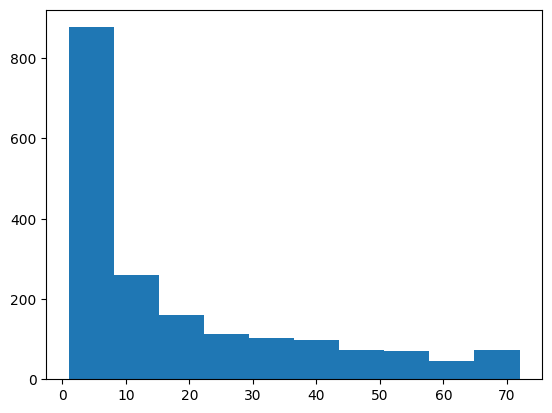

In [291]:
plt.hist(df[df["Churn"]=="Yes"]["tenure"]);

Customer tenure levels:
    
- over 48 months: customer level 3 (senior customer)

- between 24 and 48 months: customer level 2

- between 6 and 24 months: customer level 1   

- less than 6 months: customer level 0 (new customer)

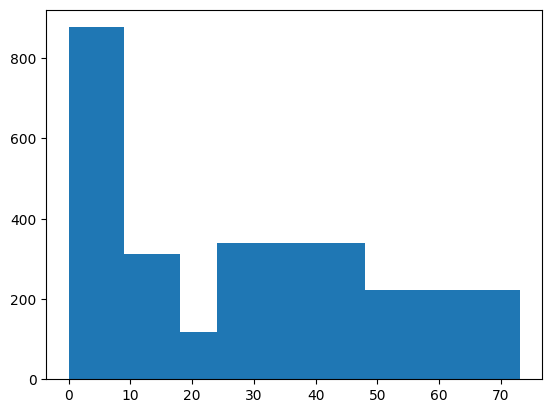

In [292]:
plt.hist(df[df["Churn"]=="Yes"]["tenure"],bins=[0,9,18,24,48,73]);

In [293]:
cust_level=[]
for i in range(len(df)):
    if df.loc[i,"tenure"]<9:
        cust_level.append(0)
    elif df.loc[i,"tenure"]<18:
        cust_level.append(1)
    elif df.loc[i,"tenure"]<24:
        cust_level.append(2)
    elif df.loc[i,"tenure"]<48:
        cust_level.append(3)
    else:
        cust_level.append(4)

In [294]:
df["customer level"]=cust_level

In [295]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customer level
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,3
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0


In [296]:
df_grouped=df.groupby(["Churn","customer level"]).size().reset_index().rename(columns={0:"counts"})
df_grouped.head()

,Churn,customer level,counts
0,No,0,847
1,No,1,589
2,No,2,361
3,No,3,1285
4,No,4,2081


In [297]:
total_counts={}
for val in df_grouped["customer level"].unique():
    total_counts[val]=df_grouped[df_grouped["customer level"]==val]["counts"].sum()

In [298]:
for i in range(len(df_grouped)):
    df_grouped.loc[i,"percent"]=str(round(100*df_grouped.loc[i,"counts"]/total_counts[df_grouped["customer level"][i]],1))+"%"

In [299]:
fig = px.bar(df_grouped, x="customer level", y="counts",color="Churn", text="percent", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(textposition='outside')
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [300]:
df[df["customer level"].isin([0,1])]["Churn"].value_counts()

Churn
No     1436
Yes    1190
Name: count, dtype: int64

In [301]:
1190/(1190+1436)

0.45316070068545317

In [302]:
(1190+1436)/7032

0.37343572241183165

In [303]:
(1190+1436)

2626

#### Summary:
Possible risk group with 45.3% churn: customers level 0 and 1, formed of 2626 customers (37.3% of total customers).

#### Intersection of risk groups (Phone Service + Internet Service + 2,3 or 4 subscribed services + low tenure)

In [304]:
df_triple_risk=df_service_risk[(df_service_risk["PhoneService"]=="Yes") & (df_service_risk["InternetService"]!="No") & (df_service_risk["tenure"]<18)] # Risk 1, 2 and 3 intersection

In [305]:
1406/7032

0.19994311717861205

In [306]:
df_triple_risk["Churn"].value_counts()

Churn
Yes    800
No     606
Name: count, dtype: int64

In [307]:
800/(800+606)

0.5689900426742532

In [308]:
800/len(df[df["Churn"]=="Yes"])

0.42803638309256287

In [309]:
df[df["Churn"]=="Yes"]["MonthlyCharges"].sum()   # Total lost revenue

139130.85

In [310]:
df_triple_risk[df_triple_risk["Churn"]=="Yes"]["MonthlyCharges"].sum()

58160.8

In [311]:
58160.8/139130.85

0.41802950244320364

#### Summary:
- The intersection of the three risk groups is 20% of the total customers. In this group, the churn rate is 57%.

- The churners in this group represent 42.8% of the total churners

- This 42.8% of total churners, are responsible for 41.8% of the lost revenue

### Other tests

#### Boxplot per Categorical Feature

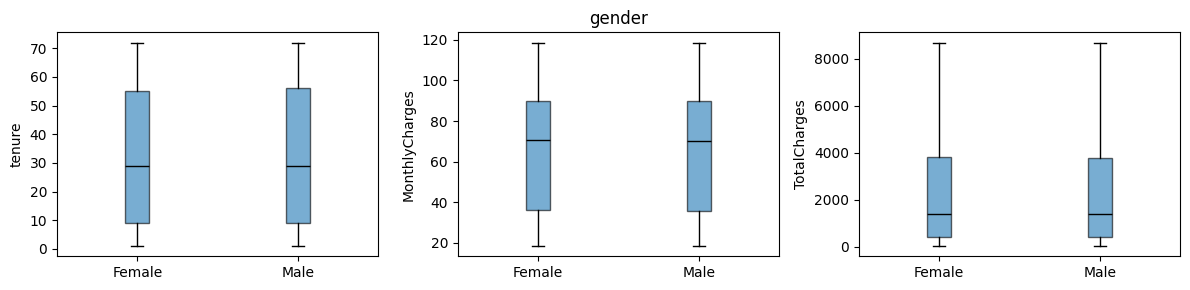

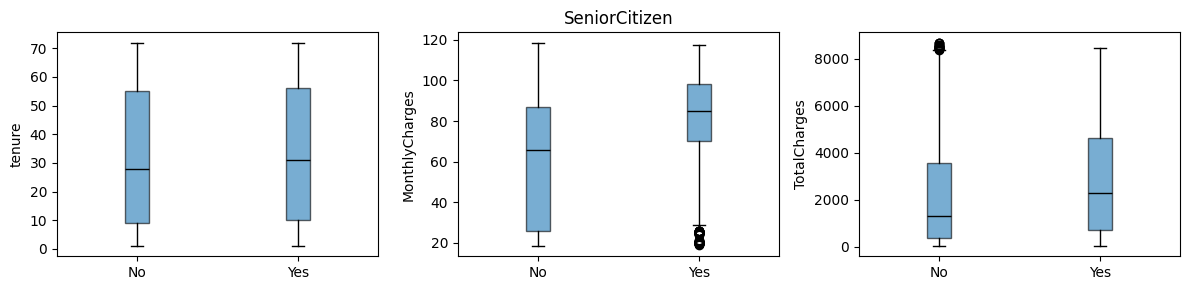

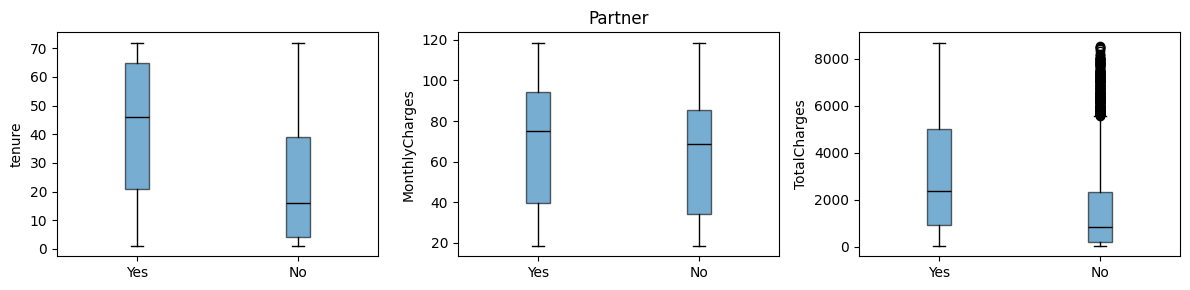

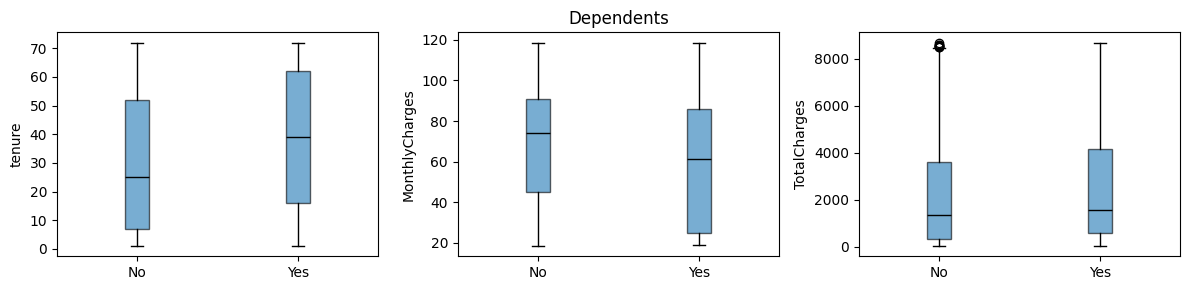

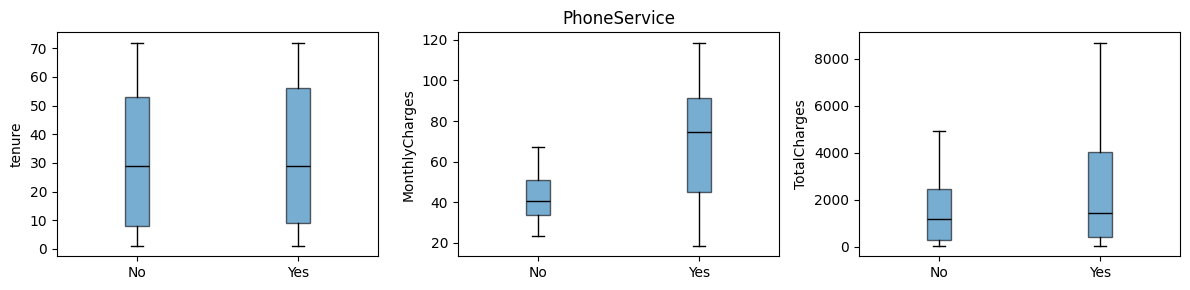

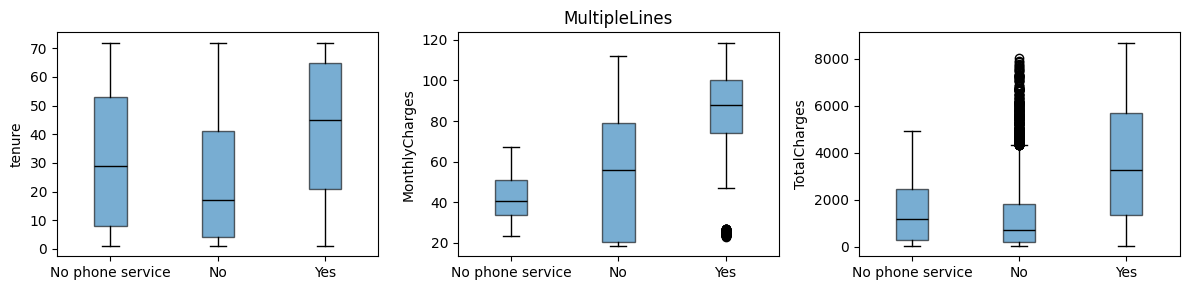

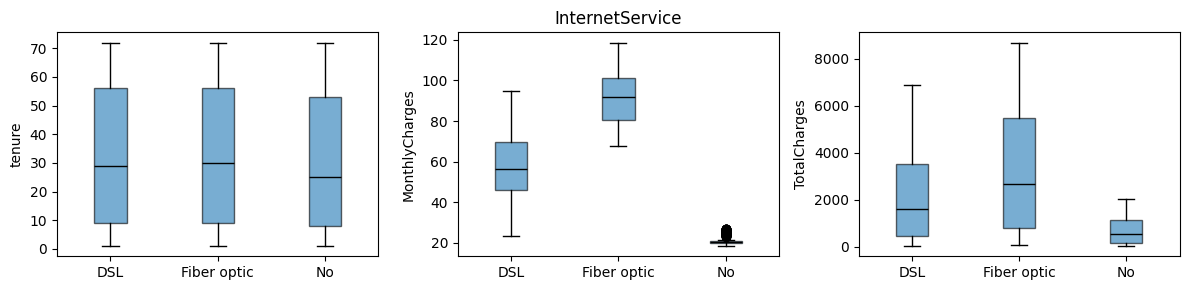

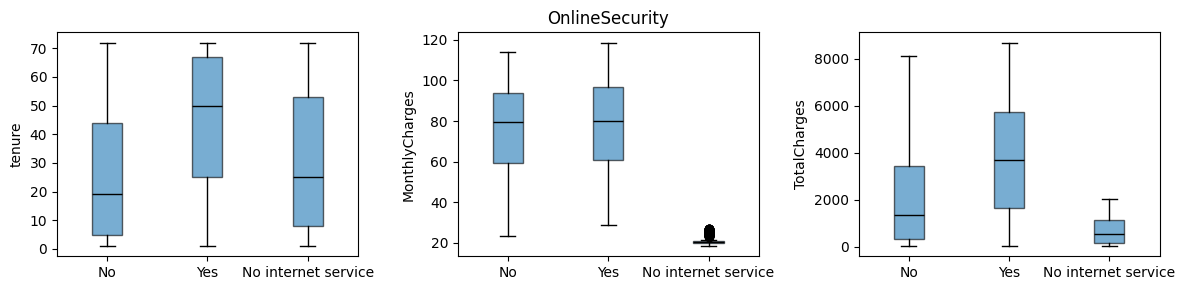

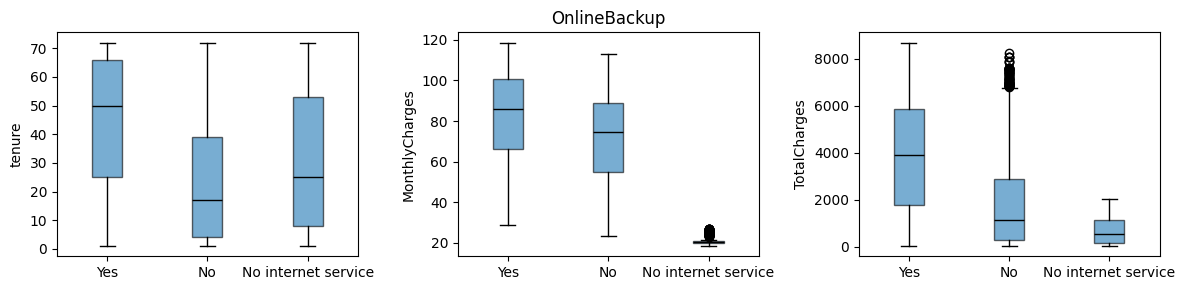

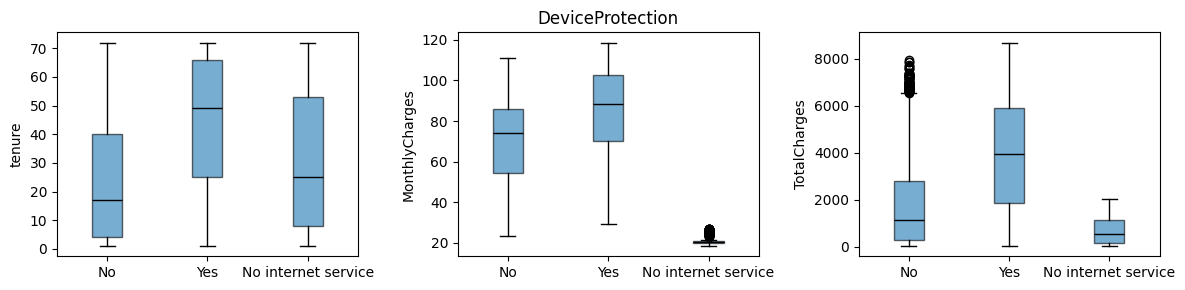

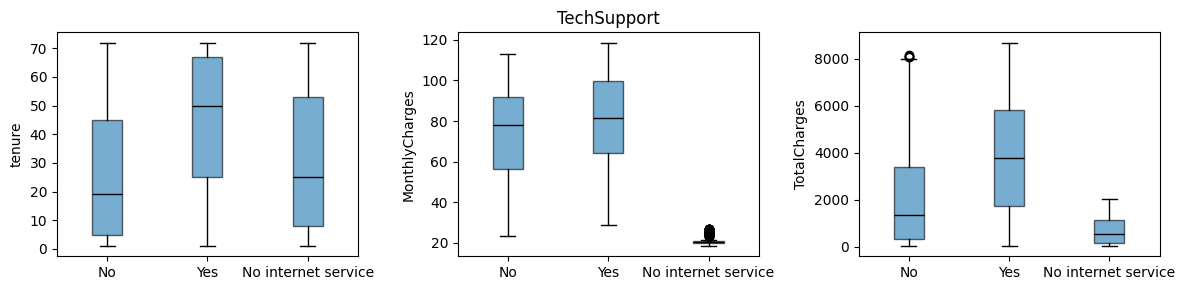

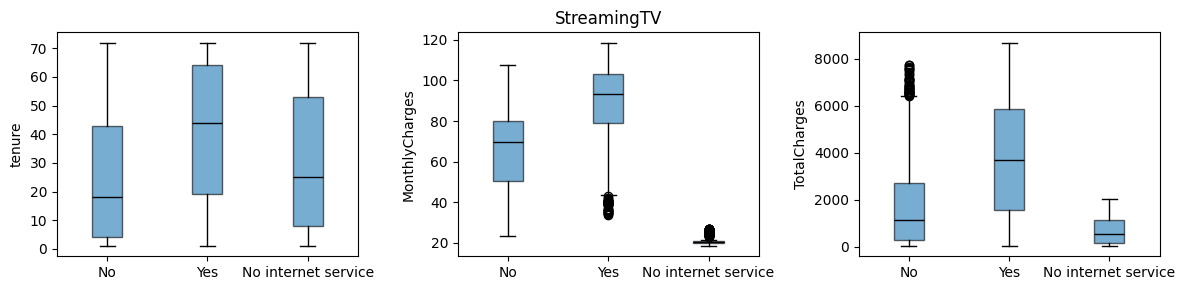

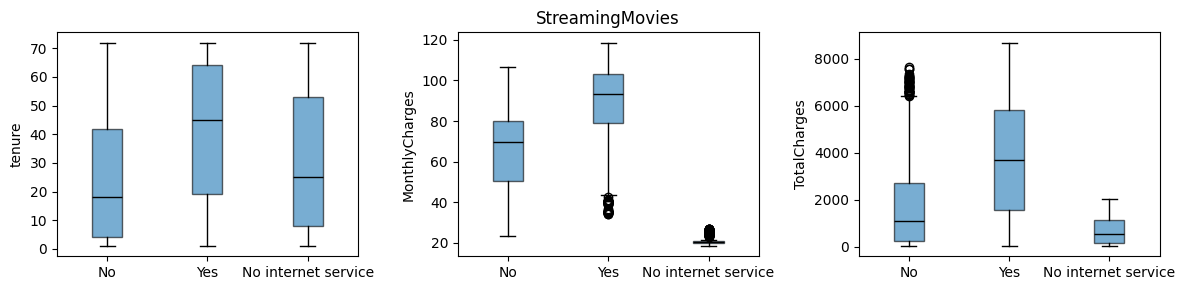

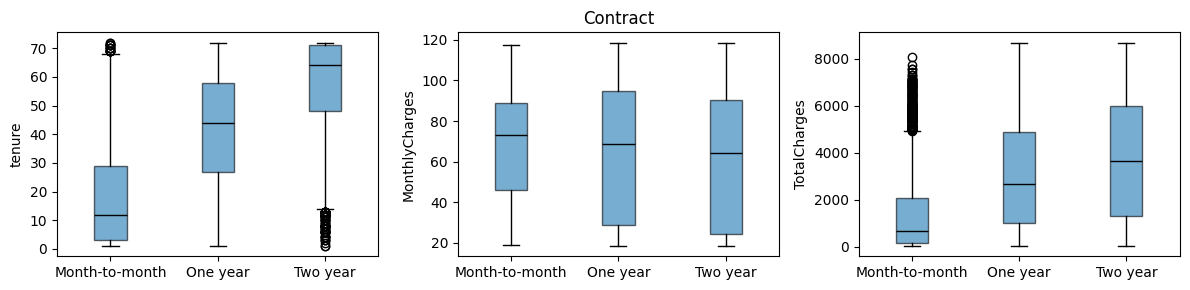

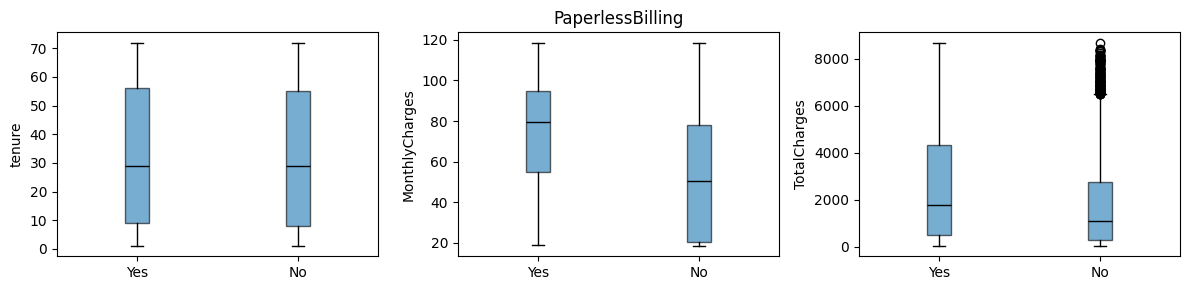

In [312]:
for col in categorical_features[:-1]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
    for i in range(len(numerical_features)):
        axs[i].boxplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                   patch_artist=True, 
                   boxprops={'facecolor': 'C0', 'alpha' : 0.6},
                   medianprops={'color': 'black'})
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))],labels=cat_values)
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()

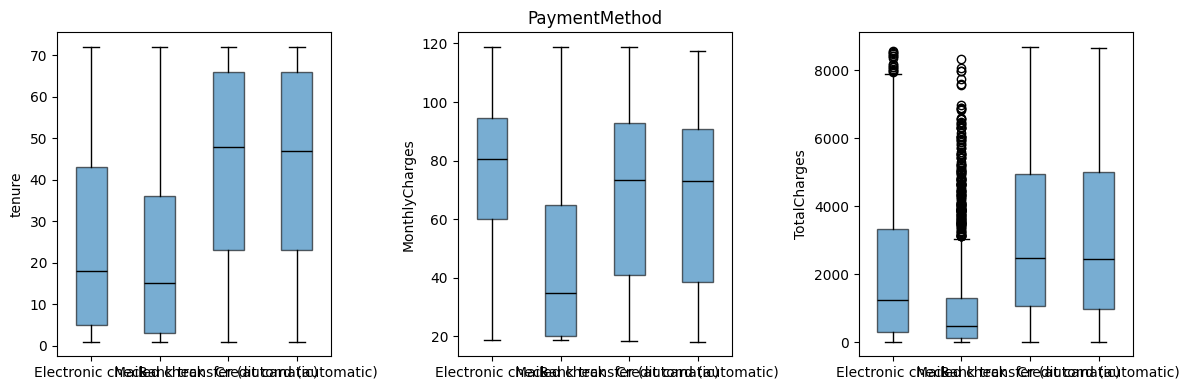

In [313]:
for col in categorical_features[-1:]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,4))
    for i in range(len(numerical_features)):
        axs[i].boxplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                   patch_artist=True, 
                   boxprops={'facecolor': 'C0', 'alpha' : 0.6},
                   medianprops={'color': 'black'})
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))], labels=cat_values)
        if col == 'Payment Method':
            axs[i].tick_params(axis='x', rotation=45)
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()

#### Violinplot per Categorical Feature

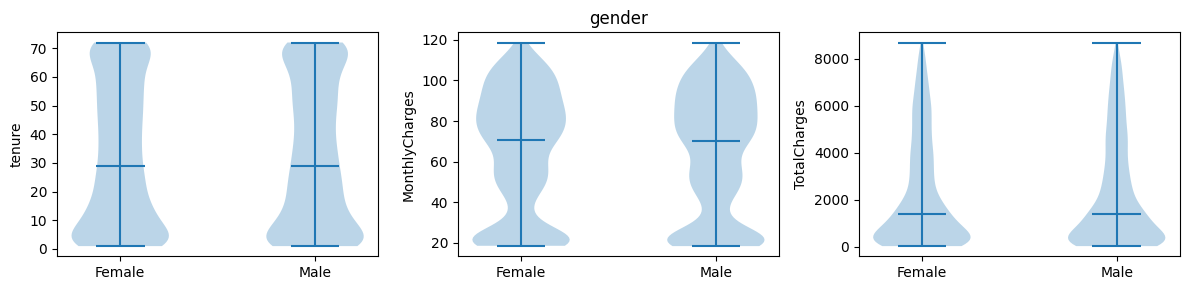

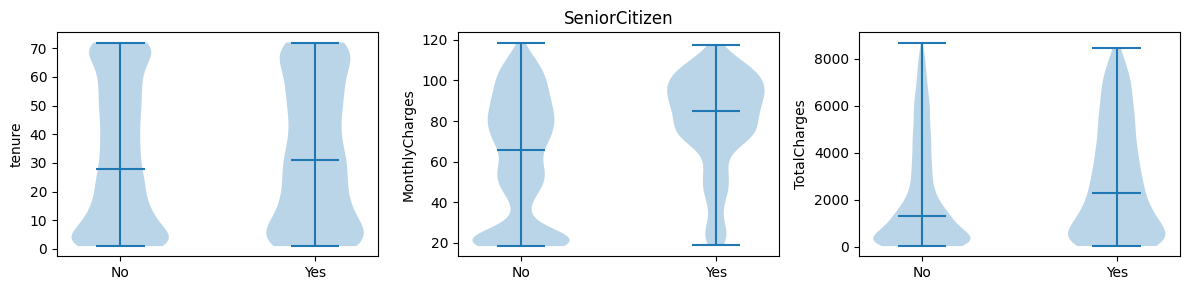

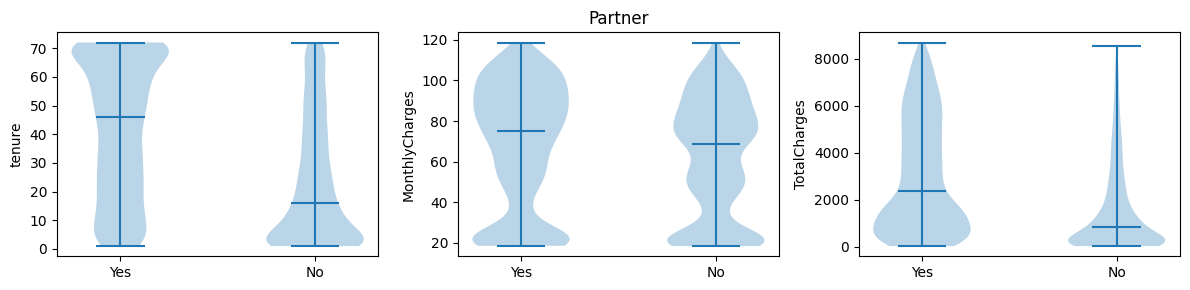

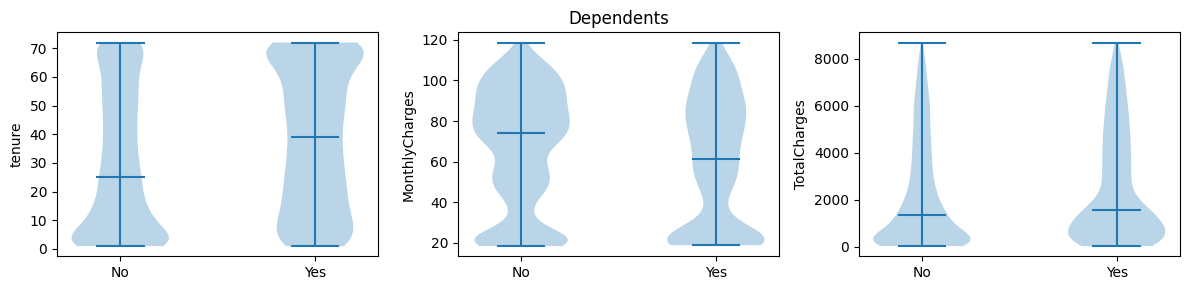

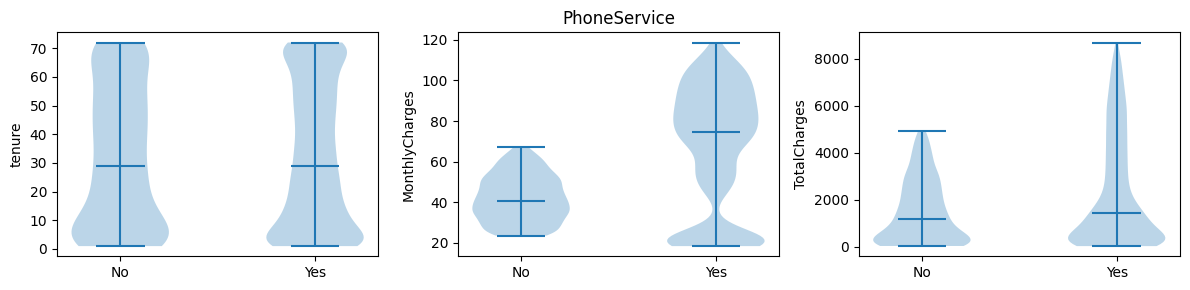

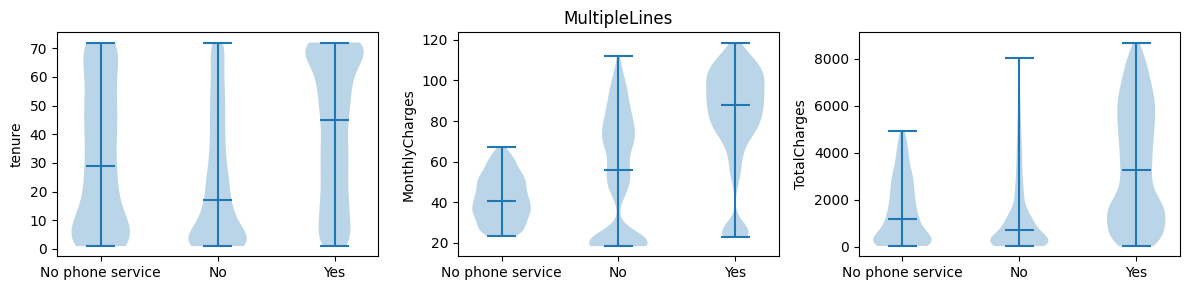

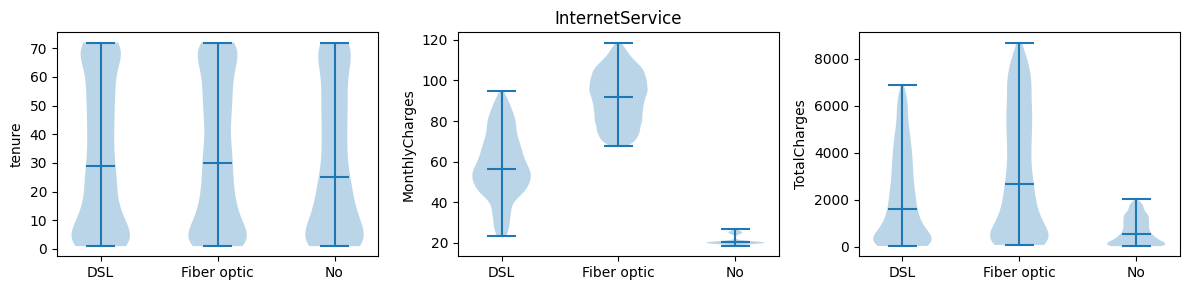

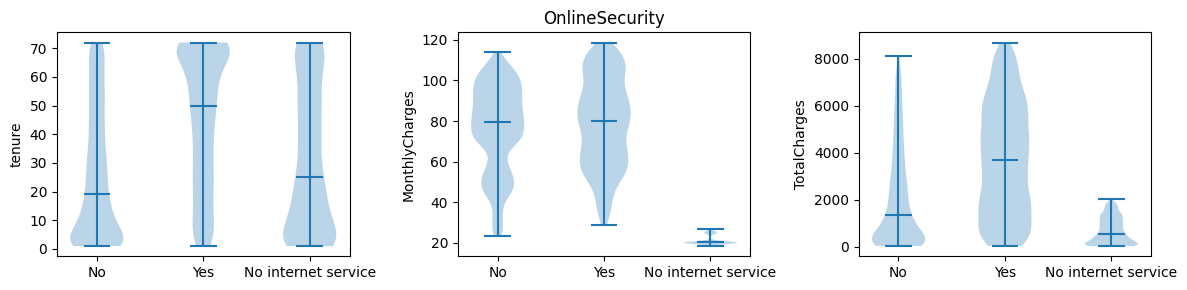

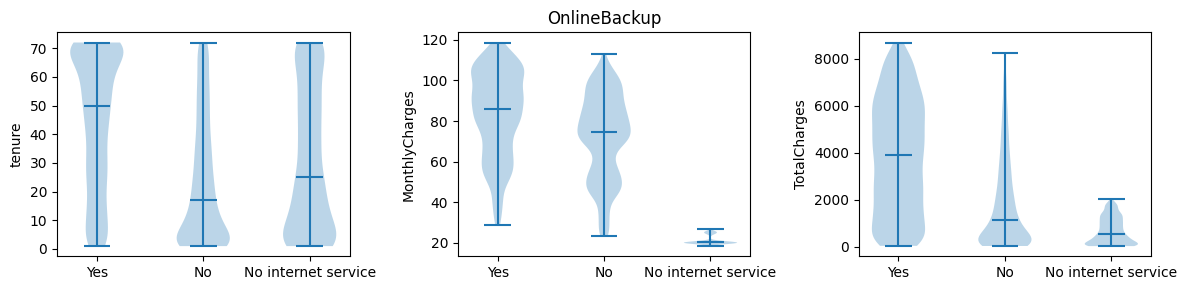

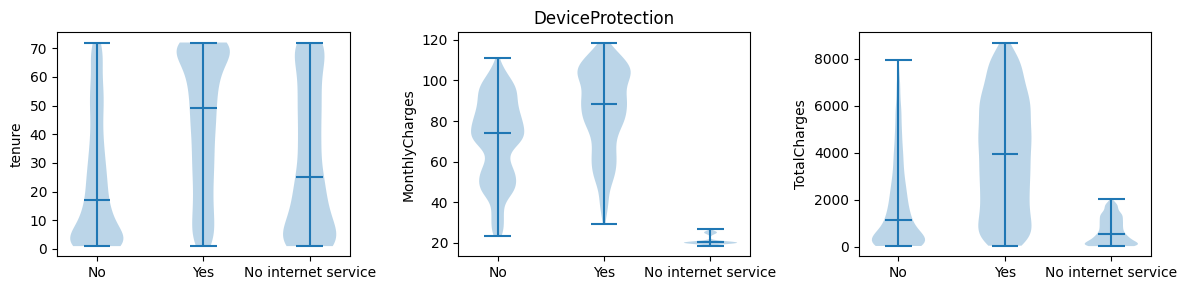

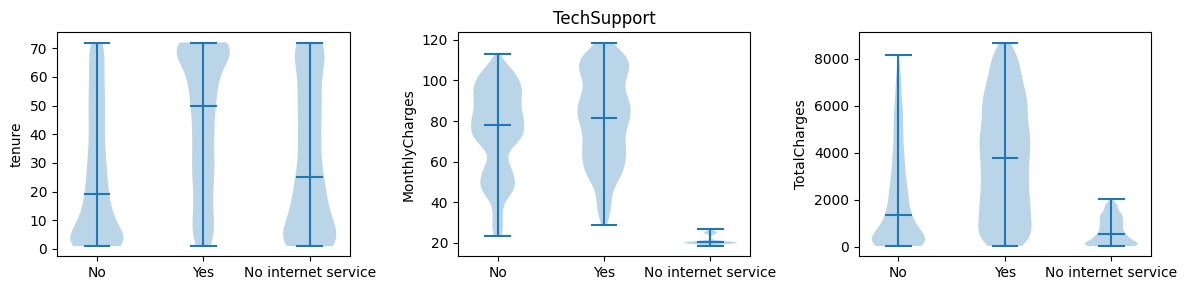

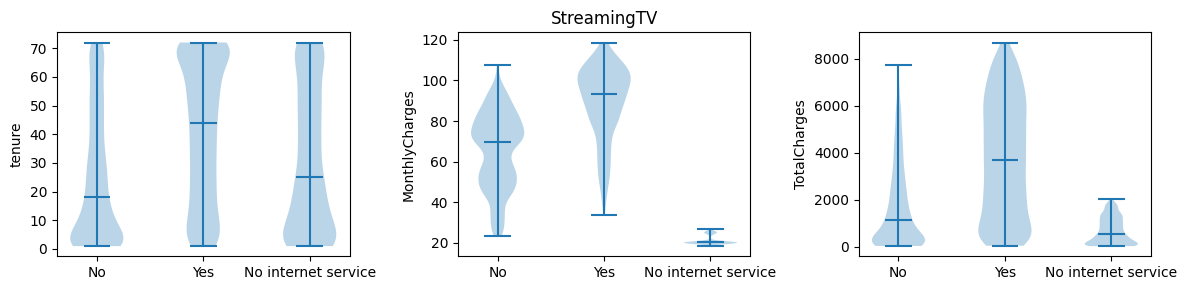

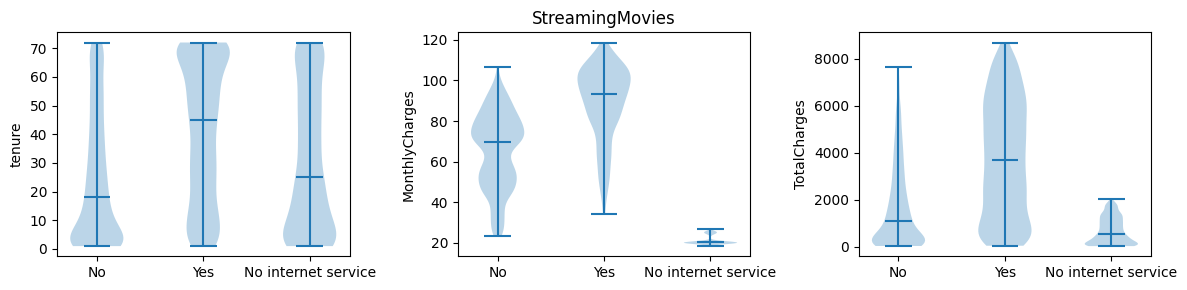

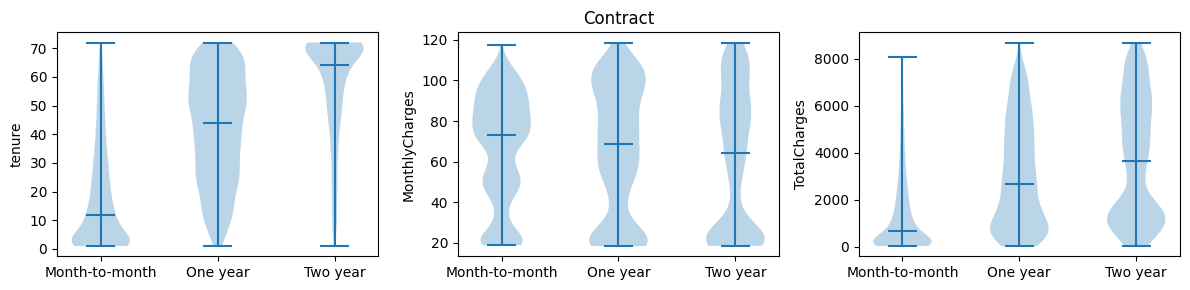

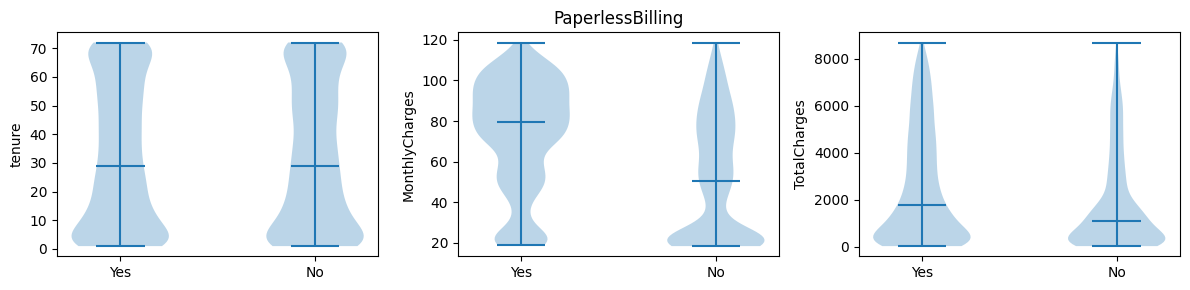

In [314]:
for col in categorical_features[:-1]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
    for i in range(len(numerical_features)):
        axs[i].violinplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                  showmeans=False,showmedians=True)
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))],
                  labels=cat_values)
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()

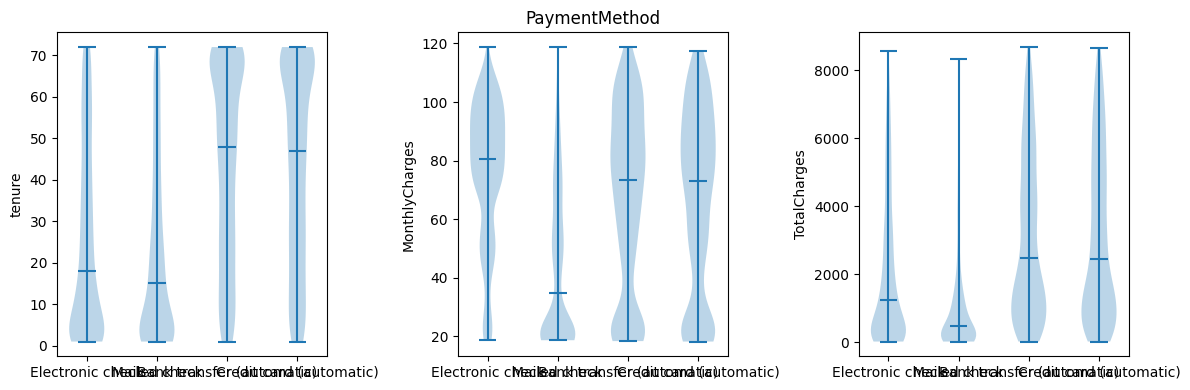

In [315]:
for col in categorical_features[-1:]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,4))
    for i in range(len(numerical_features)):
        axs[i].violinplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                  showmeans=False,showmedians=True)
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))],
                  labels=cat_values)
        if col == 'Payment Method':
            axs[i].tick_params(axis='x', rotation=45)
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()